<a href="https://colab.research.google.com/github/sandeepa-ukr/AI-Based-Crop-Predection/blob/main/crop-yield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# ML imports
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
crop_files = [
    ("apples.csv", "apples"),
    ("apricots.csv", "apricots"),
    ("areca_nuts.csv", "areca nuts"),
    ("bananas.csv", "bananas"),
    ("barley.csv", "barley"),
    ("beans_dry.csv", "beans dry"),
    ("beans_green.csv", "beans green"),
    ("cabbage.csv", "cabbage"),
    ("carrots.csv", "carrots"),
    ("cashewnuts.csv", "cashewnuts"),
    ("cauliflower.csv", "cauliflower"),
    ("cherries.csv", "cherries"),
    ("chilli_dry.csv", "chilli dry"),
    ("chilli_green.csv", "chilli green"),
    ("coconuts.csv", "coconuts"),
    ("coffee.csv", "coffee"),
    ("cucumber.csv", "cucumber"),
    ("eggplant.csv", "eggplant"),
    ("fennel_coriander.csv", "fennel coriander"),
    ("garlic.csv", "garlic"),
    ("ginger.csv", "ginger"),
    ("grapes.csv", "grapes"),
    ("groundnuts.csv", "groundnuts"),
    ("lemons.csv", "lemons"),
    ("lentils.csv", "lentils"),
    ("lettuce.csv", "lettuce"),
    ("maize.csv", "maize"),
    ("mangoes.csv", "mangoes"),
    ("melons.csv", "melons"),
    ("nutmeg.csv", "nutmeg"),
    ("okra.csv", "okra"),
    ("onions.csv", "onions"),
    ("oranges.csv", "oranges"),
    ("papaya.csv", "papaya"),
    ("peaches.csv", "peaches"),
    ("pears.csv", "pears"),
    ("peas.csv", "peas"),
    ("pepper.csv", "pepper"),
    ("pineapples.csv", "pineapples"),
    ("potatoes.csv", "potatoes"),
    ("pumpkins.csv", "pumpkins"),
    ("rice.csv", "rice"),
    ("safflower.csv", "safflower"),
    ("sesame.csv", "sesame"),
    ("soyabean.csv", "soyabean"),
    ("sugarcane.csv", "sugarcane"),
    ("tomatoes.csv", "tomatoes"),
    ("watermelon.csv", "watermelon"),
    ("wheat.csv", "wheat"),
]

keep the crop name explicitly.

In [9]:
crop_dfs = []

for fname, crop_name in crop_files:
    tmp = pd.read_csv(fname)
    tmp['crop_type'] = crop_name
    crop_dfs.append(tmp)

crop_df = pd.concat(crop_dfs, ignore_index=True)

# Remove unnecessary column
if 'Flag' in crop_df.columns:
    crop_df = crop_df.drop(columns=['Flag'])

print("Crop data shape:", crop_df.shape)
print("Unique crops:", crop_df['Item'].nunique())
print("Year range:", crop_df['Year'].min(), "-", crop_df['Year'].max())

Crop data shape: (8526, 17)
Unique crops: 49
Year range: 1965 - 2022


# Prepare climate data

In [10]:
rainfall = pd.read_csv('rainfall.csv')
temperature = pd.read_csv('temperature.csv')

for df in [rainfall, temperature]:
    if 'YEAR' in df.columns:
        df.rename(columns={'YEAR': 'Year'}, inplace=True)

    if 'Year' not in df.columns:
        raise ValueError("Climate files must contain a 'Year' column")

In [11]:
climate_df = pd.merge(
    rainfall,
    temperature,
    on='Year',
    how='inner'
)

print("Climate data shape:", climate_df.shape)
print(climate_df['Year'].min(), "-", climate_df['Year'].max())

Climate data shape: (58, 23)
1961 - 2018


#Create climate features

In [12]:
monthly_cols = [
    'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN',
    'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC'
]

In [13]:
climate_df['winter_avg'] = climate_df[
    ['DEC', 'JAN', 'FEB']
].mean(axis=1)

climate_df['summer_avg'] = climate_df[
    ['MAR', 'APR', 'MAY']
].mean(axis=1)

climate_df['monsoon_avg'] = climate_df[
    ['JUN', 'JUL', 'AUG', 'SEP']
].mean(axis=1)

climate_df['climate_std'] = climate_df[
    monthly_cols
].std(axis=1)

In [14]:
if 'ANN' in climate_df.columns:
    climate_df = climate_df.drop(columns=['ANN'])

#Create the crop-climate dataset correctly

In [15]:
yield_df = crop_df[
    crop_df['Element'].str.strip().str.lower() == 'yield'
].copy()

In [16]:
yield_df['Unit_norm'] = (
    yield_df['Unit']
    .astype(str)
    .str.strip()
    .str.lower()
)

yield_df = yield_df[
    yield_df['Unit_norm'] == 'hg/ha'
].copy()

In [17]:
print("Yield records:", len(yield_df))
print("Unique crops:", yield_df['Item'].nunique())
print("Year range:", yield_df['Year'].min(), "-", yield_df['Year'].max())

Yield records: 2842
Unique crops: 49
Year range: 1965 - 2022


In [18]:
# Display climate data info
print("Climate Data Info:")
print(climate_df.info())
print("\nFirst 5 rows of climate data:")
print(climate_df.head())

# Check for missing values
print("\nMissing values in climate data:")
print(climate_df.isnull().sum())

# Handle missing values if any
climate_df_clean = climate_df.copy()
for col in climate_df_clean.columns:
    if climate_df_clean[col].dtype in ['float64', 'int64']:
        climate_df_clean[col] = climate_df_clean[col].fillna(climate_df_clean[col].mean())

# Ensure Year column is integer
climate_df_clean['Year'] = climate_df_clean['Year'].astype(int)

print(f"\nCleaned climate data shape: {climate_df_clean.shape}")

Climate Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         58 non-null     int64  
 1   JAN          58 non-null     float64
 2   FEB          58 non-null     float64
 3   MAR          58 non-null     float64
 4   APR          58 non-null     float64
 5   MAY          58 non-null     float64
 6   JUN          58 non-null     float64
 7   JUL          58 non-null     float64
 8   AUG          58 non-null     float64
 9   SEP          58 non-null     float64
 10  OCT          58 non-null     float64
 11  NOV          58 non-null     float64
 12  DEC          58 non-null     float64
 13  Jan-Feb      58 non-null     float64
 14  Mar-May      58 non-null     float64
 15  Jun-Sep      58 non-null     float64
 16  Oct-Dec      58 non-null     float64
 17  ANNUAL       58 non-null     float64
 18  JAN-FEB      58 non-null     floa

In [19]:
climate_df_clean = climate_df_clean.drop(
    columns=['Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec']
)

In [20]:
climate_df_clean

,Year,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,...,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC,winter_avg,summer_avg,monsoon_avg,climate_std
0,1961,26.1,34.8,26.0,28.5,77.6,192.9,336.6,287.6,234.9,...,10.4,24.00,18.98,26.11,27.06,21.17,23.766667,44.033333,263.000,116.831600
1,1962,12.6,21.6,16.0,43.6,70.8,137.1,281.6,276.9,211.0,...,29.9,24.04,18.91,25.91,27.14,21.47,21.366667,43.466667,226.650,102.202809
2,1963,6.8,9.8,41.7,50.6,60.9,168.0,258.6,316.7,164.9,...,15.5,24.15,19.07,25.57,27.21,22.04,10.700000,51.066667,227.050,103.295723
3,1964,18.6,14.1,19.0,40.0,52.1,177.2,345.7,273.7,200.4,...,13.3,24.10,18.83,26.38,26.90,21.58,15.333333,37.033333,249.250,115.764773
4,1965,11.8,28.1,26.7,45.1,52.7,116.1,270.1,192.8,129.5,...,22.2,24.07,19.22,25.24,27.08,22.10,20.700000,41.500000,177.125,82.034909
5,1966,13.1,25.4,20.3,30.6,57.2,178.8,252.5,212.5,143.9,...,16.7,24.36,19.93,26.07,27.17,21.83,18.400000,36.033333,196.925,85.149784
6,1967,11.1,14.2,63.3,29.5,42.8,144.0,305.6,264.3,170.3,...,56.1,24.11,19.44,25.55,27.19,21.68,27.133333,45.200000,221.050,101.803130
7,1968,29.4,19.8,27.5,32.6,46.7,149.6,309.9,212.8,129.5,...,12.6,23.94,18.25,25.62,27.22,21.69,20.600000,35.600000,200.450,94.076981
8,1969,12.7,14.5,20.1,39.7,63.4,130.2,317.8,273.4,172.7,...,12.7,24.46,19.18,26.39,27.35,22.20,13.300000,41.066667,223.525,105.974065
9,1970,23.2,27.3,25.9,29.2,69.7,215.9,245.6,313.0,212.7,...,1.6,24.26,19.56,26.39,27.06,21.55,17.366667,41.600000,246.800,109.732596


#Correlation-Based Feature Selection


Number of climate features: 20
Features: ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg', 'climate_std']


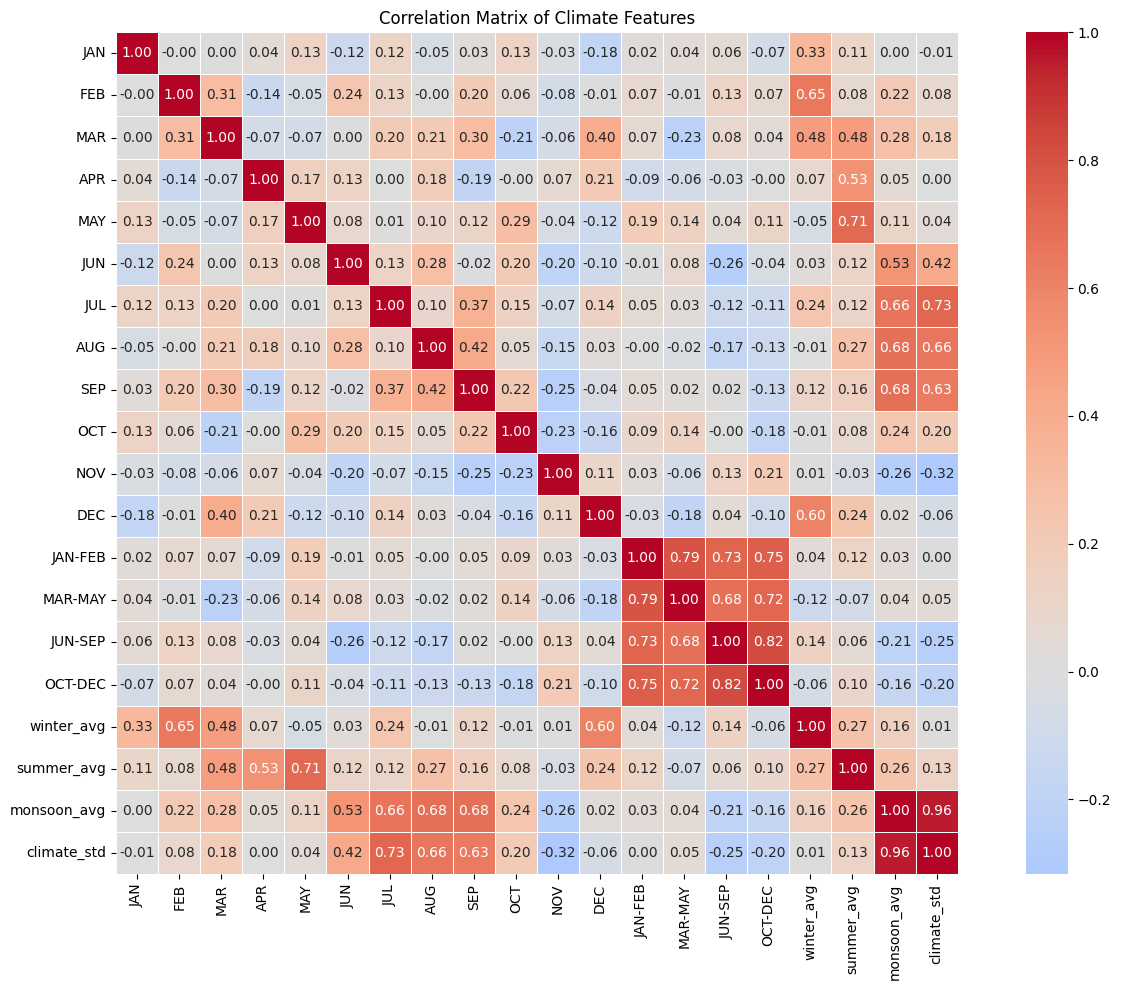


Highly correlated feature pairs (|corr| > 0.85):
     Feature 1    Feature 2  Correlation
0  monsoon_avg  climate_std     0.958369


In [21]:
# Separate features (exclude Year and any non-numeric columns)
feature_cols = [col for col in climate_df_clean.columns if col not in ['Year', 'ANNUAL']]
# Remove ANNUAL as it's already aggregated from other columns
feature_cols = [col for col in feature_cols if col != 'ANNUAL']

print(f"\nNumber of climate features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

# Correlation matrix
corr_matrix = climate_df_clean[feature_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Matrix of Climate Features')
plt.tight_layout()
plt.show()

# Identify highly correlated features (correlation > 0.85 or < -0.85)
threshold = 0.85
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

print(f"\nHighly correlated feature pairs (|corr| > {threshold}):")
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(high_corr_df.to_string())
else:
    print("No highly correlated pairs found.")

### ===================== 1. HANDLE HIGHLY CORRELATED FEATURES =====================

In [22]:
# Your climate data
print("Original climate features:", climate_df_clean.columns.tolist())

# Identify the highly correlated features you found
high_corr_pairs = [
    ('Mar-May', 'summer_avg'),
    ('Jun-Sep', 'monsoon_avg'),
    ('Jun-Sep', 'climate_std'),
    ('monsoon_avg', 'climate_std')
]

Original climate features: ['Year', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg', 'climate_std']


In [23]:
# Strategy: Keep the feature with higher variance or better interpretability
def handle_correlated_features(df, corr_threshold=0.85):
    """
    Remove highly correlated features, keeping the one with higher variance
    """
    # Calculate variance for each numeric feature
    variances = df.select_dtypes(include=[np.number]).var()

    # Get correlation matrix
    corr_matrix = df.select_dtypes(include=[np.number]).corr()

    # Find pairs with correlation above threshold
    features_to_drop = set()
    correlated_pairs = []

    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > corr_threshold:
                feat1 = corr_matrix.columns[i]
                feat2 = corr_matrix.columns[j]
                correlated_pairs.append((feat1, feat2))

                # Keep the feature with higher variance
                if variances[feat1] >= variances[feat2]:
                    features_to_drop.add(feat2)
                else:
                    features_to_drop.add(feat1)

    return features_to_drop, correlated_pairs

In [24]:
# Apply the correlation handling
features_to_drop, correlated_pairs = handle_correlated_features(
    climate_df_clean,
    corr_threshold=0.85
)

print("\nFeatures to drop due to high correlation:")
print(features_to_drop)


Features to drop due to high correlation:
{'climate_std'}


In [25]:
# Create a clean dataset without these features
climate_reduced = climate_df_clean.drop(columns=features_to_drop, errors='ignore')

print(f"\nOriginal features: {len(climate_df_clean.columns)}")
print(f"Features after removing correlated: {len(climate_reduced.columns)}")
print(f"Remaining features: {climate_reduced.columns.tolist()}")


Original features: 22
Features after removing correlated: 21
Remaining features: ['Year', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg']


In [26]:
# crop_fscore= pd.read_csv('crop_fscore_merged_data.csv')

In [ ]:
# # ===================== 2. UPDATED FEATURE LIST =====================

# # Get the remaining features (excluding Year and ANNUAL)
# feature_cols = [col for col in crop_fscore.columns
#                 if col not in ['Year', 'ANNUAL']]

# print(f"\nFeatures for analysis: {feature_cols}")
# print(f"Number of features: {len(feature_cols)}")

In [28]:
# ===================== 2. UPDATED FEATURE LIST =====================

# Get the remaining features (excluding Year and ANNUAL)
feature_cols = [col for col in climate_reduced.columns
                if col not in ['Year', 'ANNUAL']]

print(f"\nFeatures for analysis: {feature_cols}")
print(f"Number of features: {len(feature_cols)}")


Features for analysis: ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg']
Number of features: 19


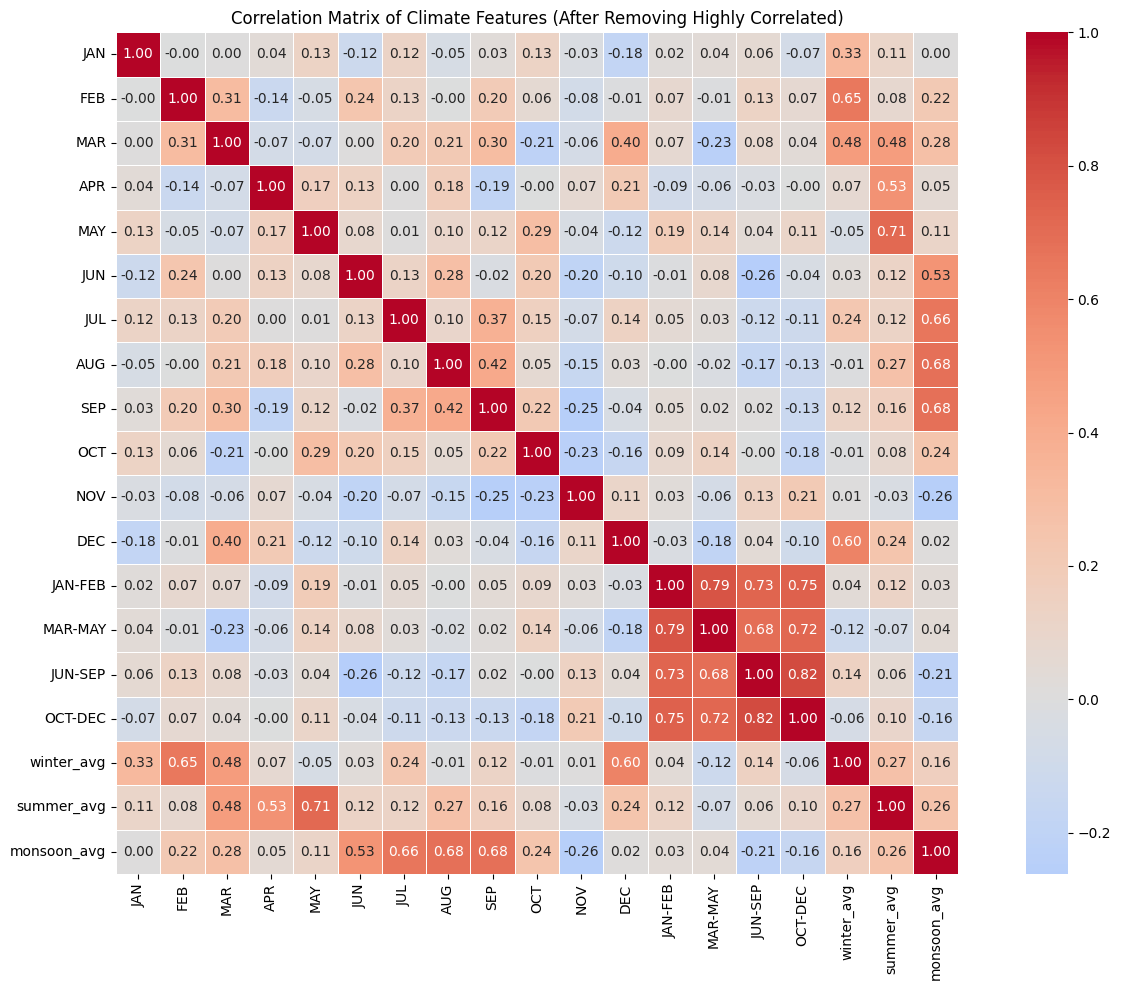

In [29]:
# ===================== 3. CORRELATION ANALYSIS WITH REMAINING FEATURES =====================

# Correlation matrix of remaining features
corr_matrix_reduced = climate_reduced[feature_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix_reduced, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Matrix of Climate Features (After Removing Highly Correlated)')
plt.tight_layout()
plt.show()

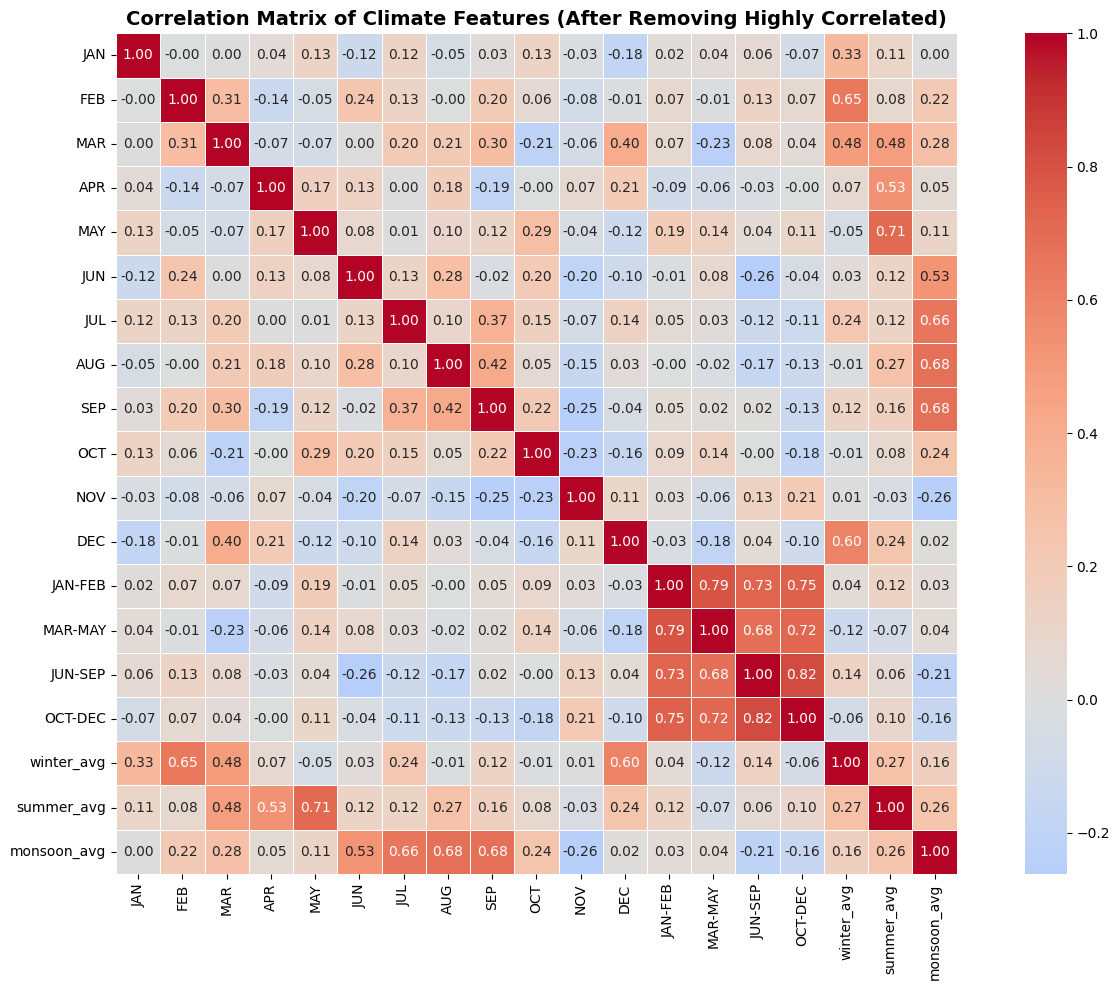

In [30]:
# ===================== 3. CORRELATION ANALYSIS WITH REMAINING FEATURES =====================

# Correlation matrix of remaining features
corr_matrix_reduced = climate_reduced[feature_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix_reduced,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5,
    square=True,
)

plt.title(
    'Correlation Matrix of Climate Features (After Removing Highly Correlated)',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

# Save figure BEFORE showing it
plt.savefig(
    'climate_correlation_matrix_reduced.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()
plt.close()

## F-SCORE ANALYSIS WITH CLEANED DATA

In [31]:
# crop_data_clean = crop_df.copy()
# crop_data_clean = crop_data_clean[['Year', 'Item', 'Value', 'crop_type']].dropna()
# crop_data_clean['Year'] = crop_data_clean['Year'].astype(int)

# FTest_data = crop_data_clean.select_dtypes(include=[np.number])
# X = FTest_data.drop(columns=['target_yield'])
# y = FTest_data['target_yield']

# k = 10  # choose how many features you want
# selector = SelectKBest(score_func=f_regression, k=k)
# X_new = selector.fit_transform(X, y)

# selected_f_features = X.columns[selector.get_support()].tolist()

# print("Top", k, "features selected using F-test:")
# print(selected_f_features)

# # Keep only these features
# FTest_data = FTest_data[selected_f_features + ['target_yield']]

=== F-Score Analysis on Climate Data Only ===
Climate data shape: (58, 19)
Features: ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg']

=== F-Score Results ===
        Feature    F_Score
12      JAN-FEB  24.958914
18  monsoon_avg  22.402208
14      JUN-SEP  17.807018
15      OCT-DEC  17.579121
17   summer_avg  16.923437
13      MAR-MAY  16.267823
16   winter_avg  15.485474
3           APR  12.570868
11          DEC  12.165149
4           MAY  11.952679


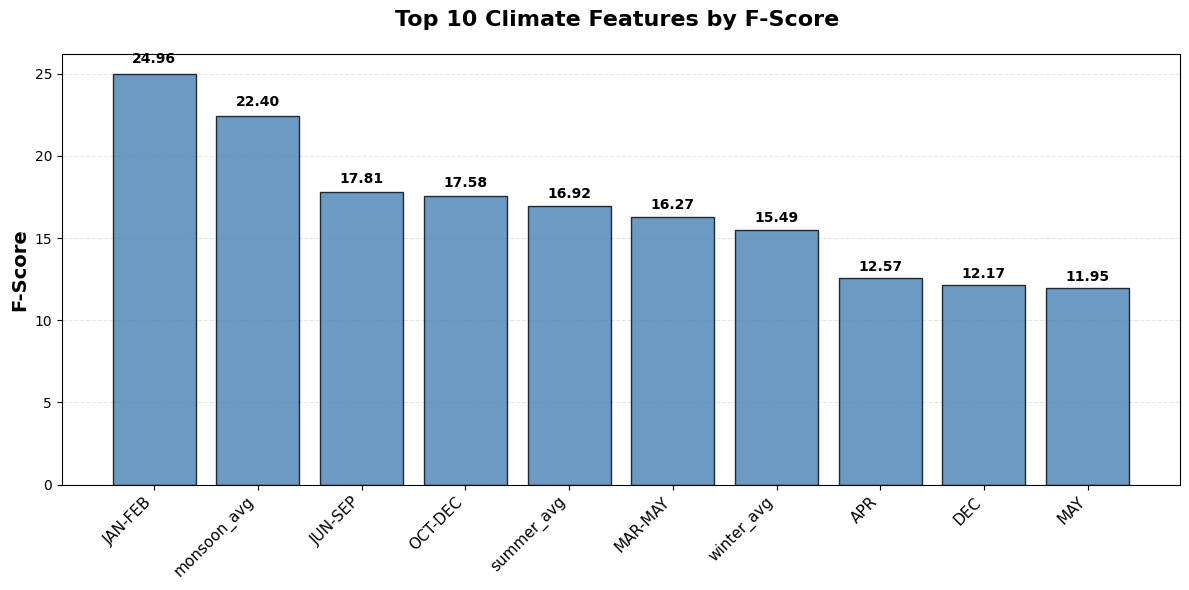


=== Detailed F-Score Analysis ===
JAN-FEB                  : F-Score = 24.9589
monsoon_avg              : F-Score = 22.4022
JUN-SEP                  : F-Score = 17.8070
OCT-DEC                  : F-Score = 17.5791
summer_avg               : F-Score = 16.9234
MAR-MAY                  : F-Score = 16.2678
winter_avg               : F-Score = 15.4855
APR                      : F-Score = 12.5709
DEC                      : F-Score = 12.1651
MAY                      : F-Score = 11.9527


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_regression
from sklearn.decomposition import PCA

# ===================== F-SCORE ANALYSIS ON CLIMATE DATA ONLY =====================

# Assuming 'climate_reduced' is your climate dataset
print("=== F-Score Analysis on Climate Data Only ===")


# Copy climate data
climate_data = climate_reduced.copy()
climate_features = climate_data.drop(
    columns=['Year', 'ANNUAL'],
    errors='ignore'
)


# Keep only numeric columns
numeric_cols = climate_features.select_dtypes(include=[np.number]).columns
climate_features = climate_features[numeric_cols]

print(f"Climate data shape: {climate_features.shape}")
print(f"Features: {climate_features.columns.tolist()}")

# Handle missing values
climate_features = climate_features.fillna(climate_features.mean())

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(climate_features)
X_scaled_df = pd.DataFrame(X_scaled, columns=climate_features.columns)

# ===================== F-SCORE USING PCA COMPONENTS =====================

# Use PCA to create pseudo-targets
n_components = min(5, X_scaled.shape[1])  # Use 5 PCA components
pca = PCA(n_components=n_components)
pca_scores = pca.fit_transform(X_scaled)

# Calculate F-scores for each feature against each PCA component
all_f_scores = []

for i in range(n_components):
    # F-test between features and PCA component
    f_scores, p_values = f_regression(X_scaled, pca_scores[:, i])
    all_f_scores.append(f_scores)

# Calculate average F-score across all PCA components
avg_f_scores = np.mean(all_f_scores, axis=0)

# Create final F-score DataFrame
f_score_df = pd.DataFrame({
    'Feature': climate_features.columns,
    'F_Score': avg_f_scores
}).sort_values('F_Score', ascending=False)

print("\n=== F-Score Results ===")
print(f_score_df.head(10))

# ===================== F-SCORE BAR CHART =====================

# Plot F-scores
plt.figure(figsize=(12, 6))
bars = plt.bar(f_score_df['Feature'].head(10), f_score_df['F_Score'].head(10),
               color='steelblue', alpha=0.8, edgecolor='black')

# Customize the plot
# plt.xlabel("Climate Features", fontsize=14, fontweight='bold')
plt.ylabel("F-Score", fontsize=14, fontweight='bold')
plt.title("Top 10 Climate Features by F-Score ",
          fontsize=16, fontweight='bold', pad=20)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=11)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
             f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add grid
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.gca().set_axisbelow(True)

# Adjust layout
plt.tight_layout()
plt.show()

# Print feature details
print("\n=== Detailed F-Score Analysis ===")
for i, row in f_score_df.head(10).iterrows():
    print(f"{row['Feature']:25s}: F-Score = {row['F_Score']:.4f}")

In [33]:
# ===================== 4. F-SCORE ANALYSIS WITH CLEANED DATA =====================

# Prepare crop data
crop_data_clean = crop_df.copy()
crop_data_clean = crop_data_clean[['Year', 'Item', 'Value', 'crop_type']].dropna()
crop_data_clean['Year'] = crop_data_clean['Year'].astype(int)

# Select top crops with sufficient data
crop_counts = crop_data_clean.groupby('crop_type').size().sort_values(ascending=False)
top_crops = crop_counts.head(10).index.tolist()

print(f"\nAnalyzing top 10 crops: {top_crops}")

# Store results for all crops
all_feature_importance = {}

for crop in top_crops:
    crop_data = crop_data_clean[crop_data_clean['crop_type'] == crop]

    if len(crop_data) < 20:
        print(f"Skipping {crop} - insufficient data")
        continue

    # Merge with climate data
    merged_data = pd.merge(
        crop_data[['Year', 'Value']],
        climate_reduced,
        on='Year',
        how='inner'
    )

    if len(merged_data) < 10:
        print(f"Skipping {crop} - insufficient merged data")
        continue

    # Prepare features and target
    X = merged_data[feature_cols]
    y = merged_data['Value']

    # Handle missing values
    X = X.fillna(X.mean())

    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

    # F-score
    f_selector = SelectKBest(score_func=f_regression, k='all')
    f_selector.fit(X_scaled_df, y)

    f_scores = pd.DataFrame({
        'Feature': X.columns,
        'F_Score': f_selector.scores_,
        'p_value': f_selector.pvalues_
    })
    f_scores = f_scores.sort_values('F_Score', ascending=False)

    # Mutual Information
    mi_selector = SelectKBest(score_func=mutual_info_regression, k='all')
    mi_selector.fit(X_scaled_df, y)

    mi_scores = pd.DataFrame({
        'Feature': X.columns,
        'MI_Score': mi_selector.scores_
    })

    # Combine
    feature_importance = pd.merge(f_scores, mi_scores, on='Feature')
    all_feature_importance[crop] = feature_importance

    print(f"\nFeature importance for {crop} (Top 10):")
    print(feature_importance.head(10))


Analyzing top 10 crops: ['apples', 'apricots', 'areca nuts', 'bananas', 'barley', 'beans dry', 'beans green', 'cabbage', 'carrots', 'cashewnuts']

Feature importance for apples (Top 10):
   Feature    F_Score   p_value  MI_Score
0  OCT-DEC  17.738791  0.000042  0.109607
1  JUN-SEP  16.622605  0.000072  0.026011
2  MAR-MAY  12.433832  0.000550  0.000000
3  JAN-FEB  12.289229  0.000591  0.000000
4      SEP   0.977011  0.324430  0.000000
5      FEB   0.451276  0.502699  0.000000
6      OCT   0.444867  0.505743  0.000000
7      DEC   0.192886  0.661118  0.029914
8      MAY   0.184332  0.668254  0.000000
9      JAN   0.158023  0.691513  0.000000

Feature importance for apricots (Top 10):
      Feature   F_Score   p_value  MI_Score
0     MAR-MAY  0.317255  0.574051  0.000000
1     OCT-DEC  0.231964  0.630729  0.031162
2     JAN-FEB  0.134669  0.714124  0.000000
3     JUN-SEP  0.123661  0.725560  0.000000
4  summer_avg  0.119999  0.729491  0.000000
5         MAR  0.065615  0.798161  0.000000



==================== OVERALL FEATURE IMPORTANCE ====================
             Mean_F_Score  Std_F_Score  Rank_Mean
Feature                                          
OCT-DEC         15.457976    10.063647        1.0
JUN-SEP         14.616744     8.902503        2.0
MAR-MAY         12.888065     8.654508        3.0
JAN-FEB         11.573659     7.485997        4.0
SEP              0.824475     0.518519        5.0
DEC              0.580805     0.377267        6.0
OCT              0.280345     0.250646        7.0
winter_avg       0.213421     0.162182        8.0
NOV              0.197931     0.184098        9.0
FEB              0.171149     0.134748       10.0
JAN              0.131172     0.127430       11.0
MAY              0.130213     0.127540       12.0
MAR              0.126478     0.102501       13.0
summer_avg       0.106011     0.094824       14.0
monsoon_avg      0.094945     0.157878       15.0
JUL              0.043756     0.043918       16.0
JUN              0.041888    

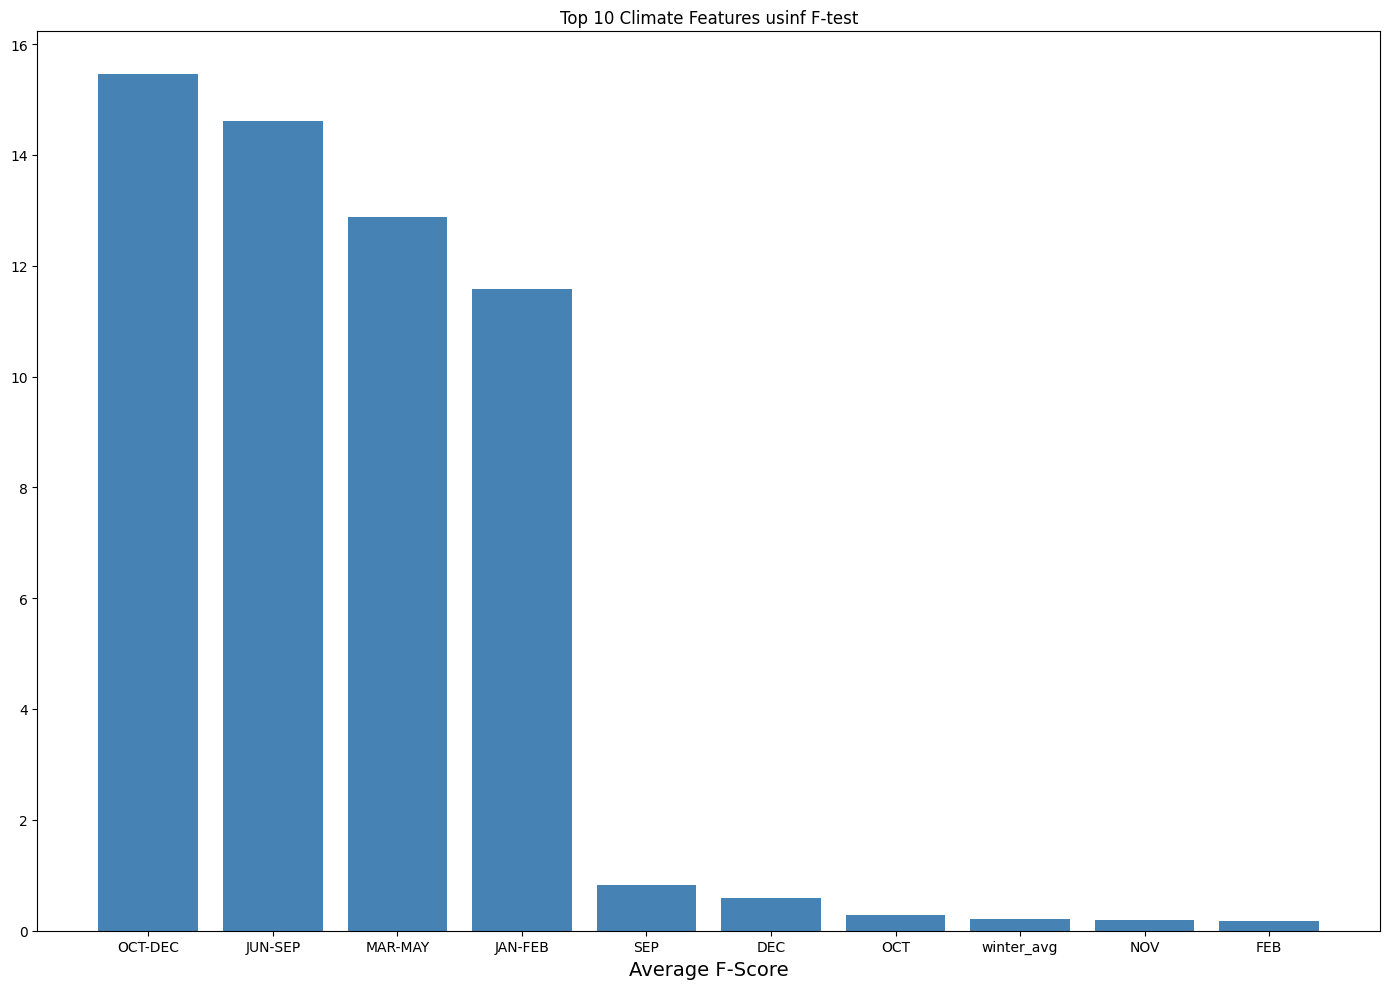

In [34]:
# ===================== 5. AGGREGATE FEATURE IMPORTANCE =====================

# Combine results across crops
if all_feature_importance:
    # Create dataframe with F-scores for each crop
    crop_features_df = pd.DataFrame()

    for crop, importance_df in all_feature_importance.items():
        temp = importance_df[['Feature', 'F_Score']].set_index('Feature')
        crop_features_df[f'{crop}_F_Score'] = temp['F_Score']

    # Fill NaN with 0
    crop_features_df = crop_features_df.fillna(0)

    # Calculate statistics
    crop_features_df['Mean_F_Score'] = crop_features_df.mean(axis=1)
    crop_features_df['Std_F_Score'] = crop_features_df.std(axis=1)
    crop_features_df['Max_F_Score'] = crop_features_df.max(axis=1)
    crop_features_df['Min_F_Score'] = crop_features_df.min(axis=1)
    crop_features_df['Rank_Mean'] = crop_features_df['Mean_F_Score'].rank(ascending=False)

    # Sort by mean F-score
    crop_features_df = crop_features_df.sort_values('Mean_F_Score', ascending=False)

    print("\n\n==================== OVERALL FEATURE IMPORTANCE ====================")
    print(crop_features_df[['Mean_F_Score', 'Std_F_Score', 'Rank_Mean']].head(20))

    # Visualize top features
    plt.figure(figsize=(14, 10))
    top_features = crop_features_df.head(10)
    plt.bar(top_features.index, top_features['Mean_F_Score'],
            #  xerr=top_features['Std_F_Score'] if not top_features['Std_F_Score'].isna().all() else None,
             color='steelblue')
    plt.xlabel("Features", fontsize=14)
    plt.xlabel('Average F-Score')
    plt.title('Top 10 Climate Features usinf F-test')
    # plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# # PLOT F-TEST BAR GRAPH
# # -------------------------
# plt.figure(figsize=(7, 4))
# plt.bar(selected_scores['Feature'], selected_scores['F_score'])
# plt.xticks(rotation=90)
# plt.xlabel("Features", fontsize=14)
# plt.ylabel("F-score (ANOVA)", fontsize=14)
# plt.title("Top {} Features Selected Using F-test".format(k))
# plt.tight_layout()
# plt.show()


Features selected by F-score threshold (top 30%):
['OCT-DEC', 'JUN-SEP', 'MAR-MAY', 'JAN-FEB', 'SEP', 'DEC']
Number: 6

Final selected features (after correlation reduction):
['OCT-DEC', 'SEP', 'DEC']
Number: 3

Random Forest Feature Importance:
            Mean_RF_Importance
Feature                       
OCT-DEC               0.153231
JUN-SEP               0.106908
MAR-MAY               0.083040
JAN-FEB               0.066073
summer_avg            0.060314
JUN                   0.049643
OCT                   0.044489
NOV                   0.042460
MAR                   0.041778
SEP                   0.040920
MAY                   0.040632
JAN                   0.039616
AUG                   0.036009
APR                   0.035904
FEB                   0.035367

Final features after combining with RF: ['MAR', 'AUG', 'JUN', 'OCT-DEC', 'JAN-FEB', 'APR', 'NOV', 'MAR-MAY', 'JAN', 'SEP', 'summer_avg', 'DEC', 'MAY', 'FEB', 'OCT', 'JUN-SEP']
Total features: 16

Final climate dataset shape: 

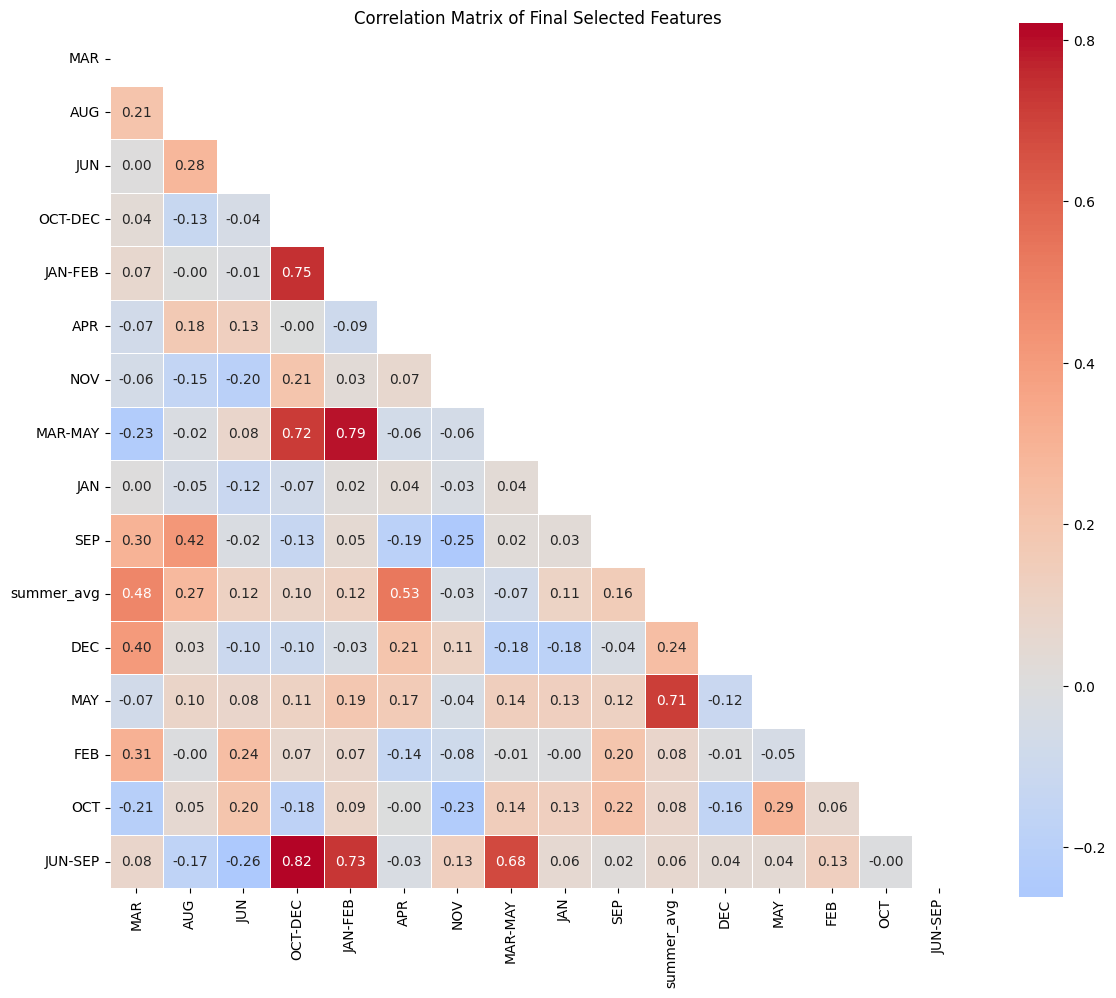


Feature selection completed successfully!


In [35]:

if all_feature_importance:

  # ===================== 6. SELECT FINAL FEATURES =====================

    # Method 1: Select features with high F-score
    threshold_mean = crop_features_df['Mean_F_Score'].quantile(0.70)  # Top 30%
    high_f_score_features = crop_features_df[
        crop_features_df['Mean_F_Score'] >= threshold_mean
    ].index.tolist()

    print(f"\nFeatures selected by F-score threshold (top 30%):")
    print(high_f_score_features)
    print(f"Number: {len(high_f_score_features)}")

    # Method 2: Select features with low correlation among themselves
    def select_low_correlation_features(features, df, corr_threshold=0.7):
        """
        Select features with low correlation among themselves
        """
        if len(features) == 0:
            return []

        # Get correlation matrix for these features
        corr_matrix = df[features].corr()

        selected = []
        for feature in features:
            if not selected:
                selected.append(feature)
            else:
                # Check if feature is correlated with any selected feature
                correlated = False
                for sel in selected:
                    if abs(corr_matrix.loc[feature, sel]) > corr_threshold:
                        correlated = True
                        break
                if not correlated:
                    selected.append(feature)
        return selected

    # Select features based on F-score first, then reduce correlation
    final_features = select_low_correlation_features(
        high_f_score_features,
        climate_reduced,
        corr_threshold=0.7
    )

    print(f"\nFinal selected features (after correlation reduction):")
    print(final_features)
    print(f"Number: {len(final_features)}")

    # ===================== 7. RANDOM FOREST FEATURE IMPORTANCE (Optional) =====================

    # Use Random Forest as an alternative method
    rf_importance = {}

    for crop in top_crops[:5]:  # Use first 5 crops for RF
        crop_data = crop_data_clean[crop_data_clean['crop_type'] == crop]

        if len(crop_data) < 20:
            continue

        merged_data = pd.merge(
            crop_data[['Year', 'Value']],
            climate_reduced,
            on='Year',
            how='inner'
        )

        if len(merged_data) < 10:
            continue

        X = merged_data[feature_cols].fillna(0)
        y = merged_data['Value']

        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X, y)

        importance = pd.DataFrame({
            'Feature': X.columns,
            'RF_Importance': rf.feature_importances_
        }).sort_values('RF_Importance', ascending=False)

        rf_importance[crop] = importance

    # Aggregate RF importance
    if rf_importance:
        rf_importance_df = pd.DataFrame()

        for crop, importance_df in rf_importance.items():
            temp = importance_df[['Feature', 'RF_Importance']].set_index('Feature')
            rf_importance_df[f'{crop}_RF'] = temp['RF_Importance']

        rf_importance_df = rf_importance_df.fillna(0)
        rf_importance_df['Mean_RF_Importance'] = rf_importance_df.mean(axis=1)
        rf_importance_df = rf_importance_df.sort_values('Mean_RF_Importance', ascending=False)

        print("\nRandom Forest Feature Importance:")
        print(rf_importance_df[['Mean_RF_Importance']].head(15))

        # Combine with F-score selection
        rf_top_features = rf_importance_df.head(15).index.tolist()
        final_features = list(set(final_features) | set(rf_top_features))

        print(f"\nFinal features after combining with RF: {final_features}")
        print(f"Total features: {len(final_features)}")

# ===================== 8. CREATE FINAL CLIMATE DATASET =====================

# Create final dataset with selected features
climate_final = climate_reduced[['Year'] + final_features].copy()

print(f"\nFinal climate dataset shape: {climate_final.shape}")
print("First 5 rows:")
print(climate_final.head())

# Save the final dataset
climate_final.to_csv('climate_data_selected_features.csv', index=False)
print("\nSaved final climate dataset to 'climate_data_selected_features.csv'")

# ===================== 9. SUMMARY STATISTICS =====================

print("\n==================== SUMMARY ====================")
print(f"Original features (excluding Year): {len(climate_df_clean.columns) - 1}")
print(f"Features after removing correlated: {len(feature_cols)}")
print(f"Features selected by F-score: {len(high_f_score_features)}")
print(f"Final selected features: {len(final_features)}")
print(f"Reduction: {len(climate_df_clean.columns) - 1 - len(final_features)} features")
print(f"Reduction percentage: {((len(climate_df_clean.columns) - 1 - len(final_features)) / (len(climate_df_clean.columns) - 1) * 100):.1f}%")

print(f"\nFinal selected features:\n{final_features}")

# ===================== 10. VISUALIZATION OF CORRELATIONS =====================

# Plot correlation matrix of final features
if len(final_features) > 1:
    plt.figure(figsize=(12, 10))
    final_corr = climate_final[final_features].corr()

    # Mask upper triangle
    mask = np.triu(np.ones_like(final_corr, dtype=bool))

    sns.heatmap(final_corr, mask=mask, annot=True, cmap='coolwarm',
                center=0, fmt='.2f', linewidths=0.5, square=True)
    plt.title('Correlation Matrix of Final Selected Features')
    plt.tight_layout()
    plt.show()

print("\nFeature selection completed successfully!")

In [36]:
# ============================================================
# CORRELATION-BASED FEATURE SELECTION FOR CLIMATE DATA
# ============================================================

# 1. Select numerical climate features
climate_numeric = climate_df.select_dtypes(include=[np.number]).copy()

# Remove Year because it is a time identifier, not a climate variable
if 'Year' in climate_numeric.columns:
    climate_numeric = climate_numeric.drop(columns=['Year'])

print("Original climate features:")
print(climate_numeric.columns.tolist())
print("Number of features:", len(climate_numeric.columns))




Original climate features:
['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'ANNUAL', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg', 'climate_std']
Number of features: 25


COMPLETE DATASET SHAPE:
Total samples: 7938
Total features: 29
Years covered: 1965 - 2018
Crops covered: 49

First few rows:
   Year    Item  Value crop_type   JAN   FEB   MAR   APR   MAY    JUN  ...  \
0  1965  Apples  44500    apples  11.8  28.1  26.7  45.1  52.7  116.1  ...   
1  1966  Apples  38500    apples  13.1  25.4  20.3  30.6  57.2  178.8  ...   
2  1967  Apples  33700    apples  11.1  14.2  63.3  29.5  42.8  144.0  ...   
3  1968  Apples  26500    apples  29.4  19.8  27.5  32.6  46.7  149.6  ...   
4  1969  Apples  21700    apples  12.7  14.5  20.1  39.7  63.4  130.2  ...   

   Oct-Dec  ANNUAL  JAN-FEB  MAR-MAY  JUN-SEP  OCT-DEC  winter_avg  \
0     74.4   24.07    19.22    25.24    27.08    22.10   20.700000   
1    123.7   24.36    19.93    26.07    27.17    21.83   18.400000   
2    108.9   24.11    19.44    25.55    27.19    21.68   27.133333   
3    101.6   23.94    18.25    25.62    27.22    21.69   20.600000   
4    103.4   24.46    19.18    26.39    27.35    22.20  

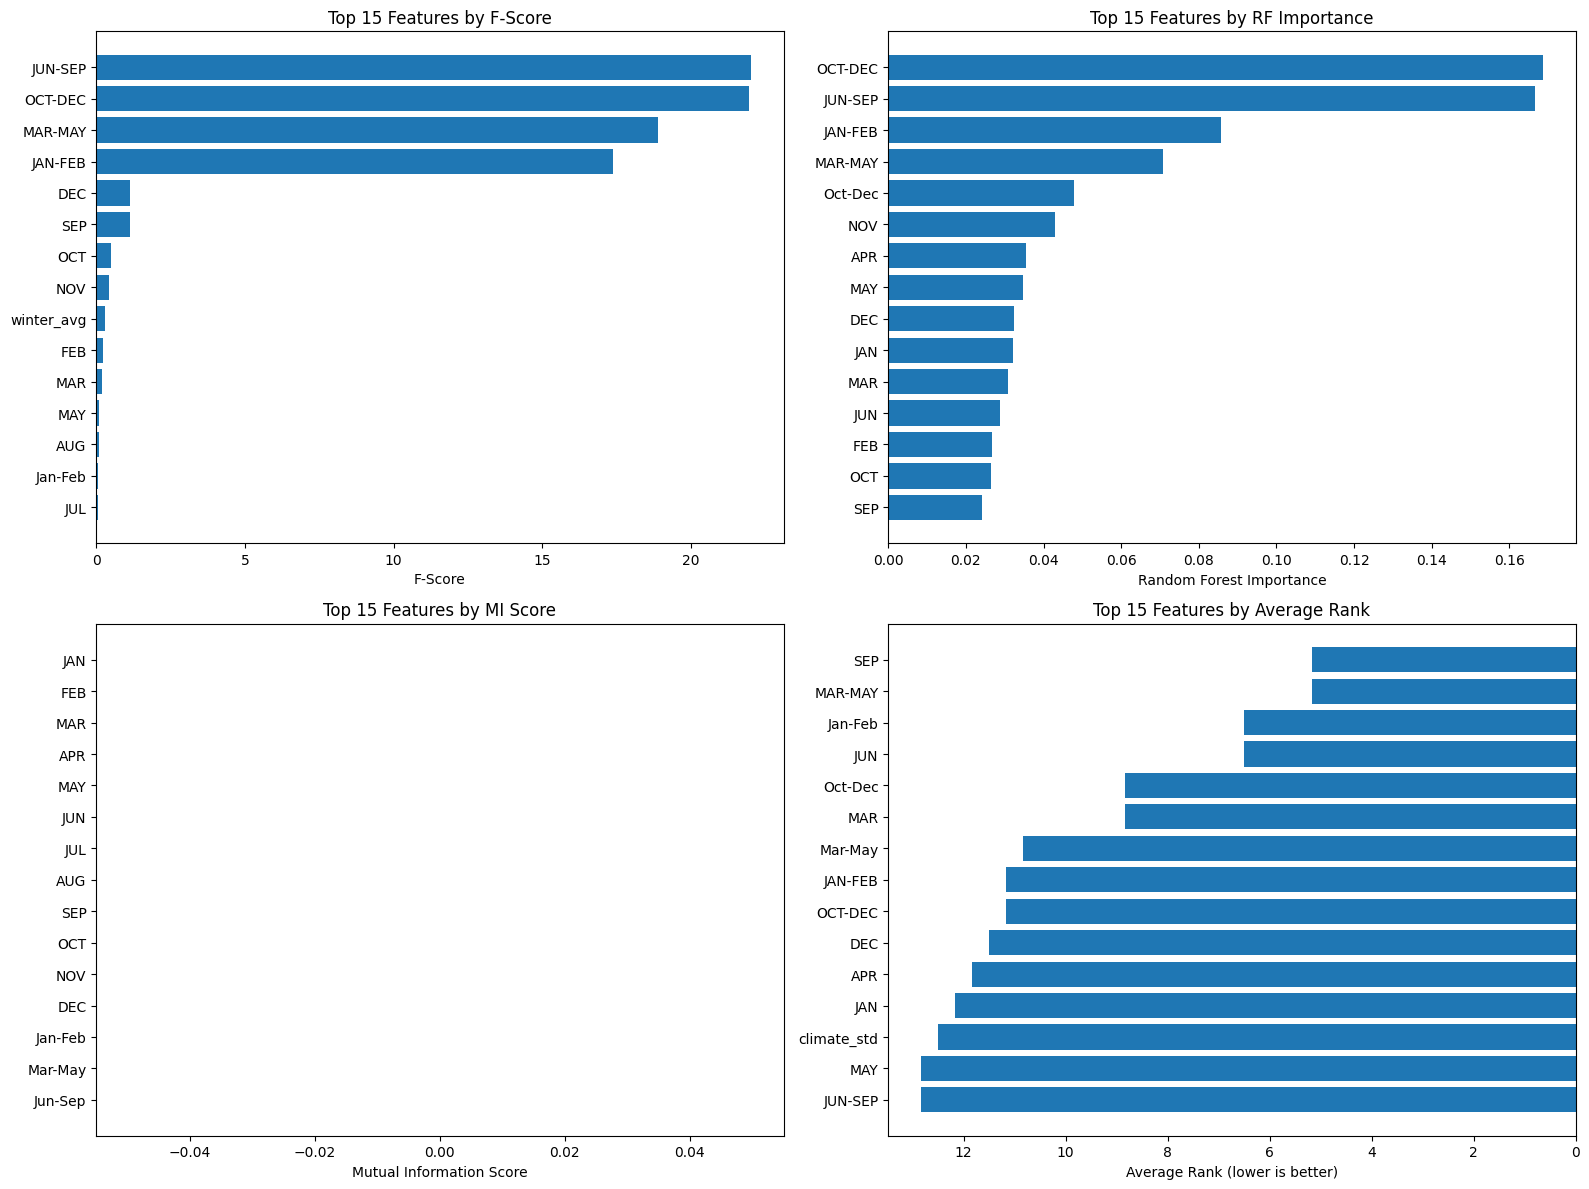

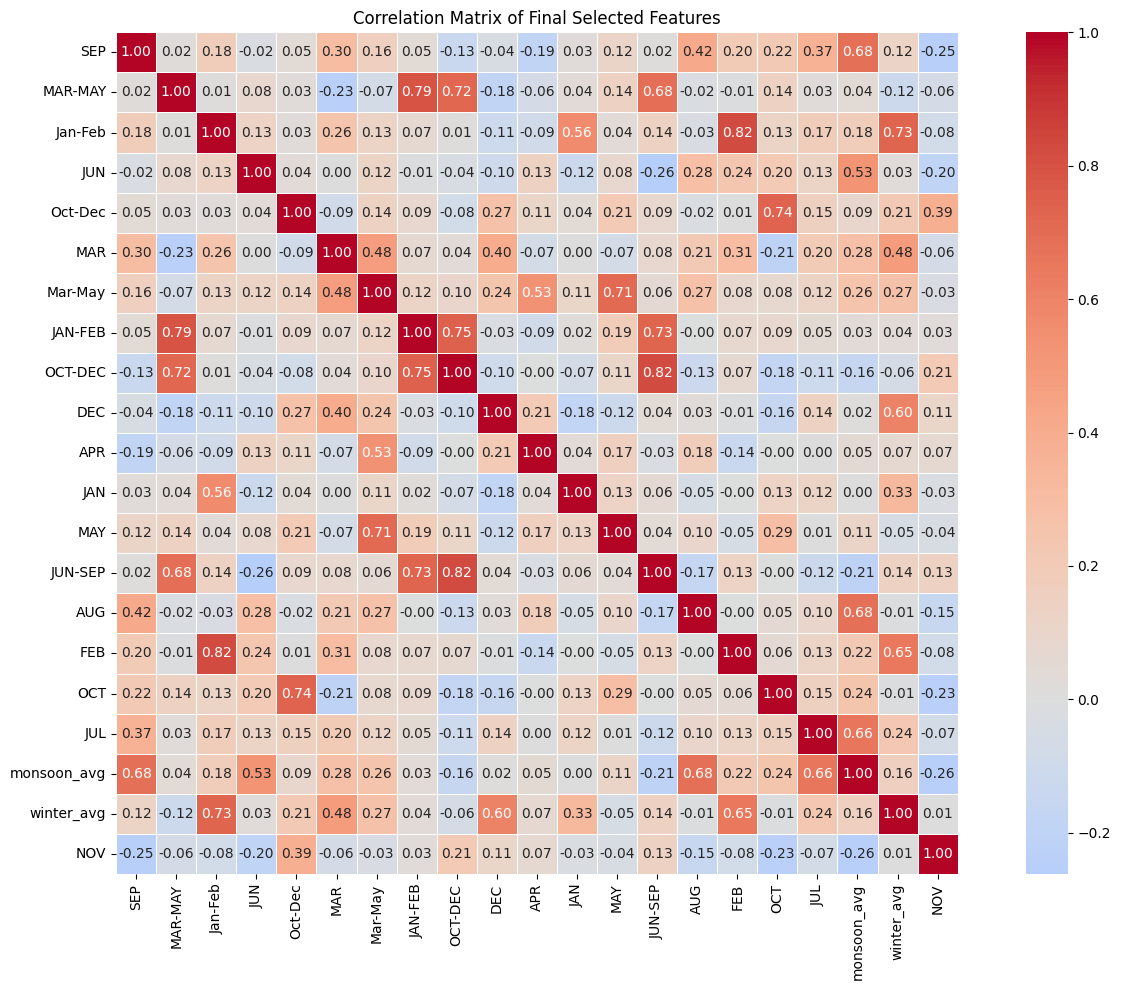


SUMMARY REPORT
Total climate features: 24
Features after correlation selection: 21
Features after F-score selection: 6
Features after RF importance: 6
Features after MI selection: 24
Final selected features: 21
Feature reduction: 3 (12.5%)

Final features: ['SEP', 'MAR-MAY', 'Jan-Feb', 'JUN', 'Oct-Dec', 'MAR', 'Mar-May', 'JAN-FEB', 'OCT-DEC', 'DEC', 'APR', 'JAN', 'MAY', 'JUN-SEP', 'AUG', 'FEB', 'OCT', 'JUL', 'monsoon_avg', 'winter_avg', 'NOV']

✅ Feature selection completed successfully!


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# ===================== 1. PREPARE COMPLETE DATASET =====================

# Clean climate data
climate_df_clean = climate_df.copy()
for col in climate_df_clean.columns:
    if climate_df_clean[col].dtype in ['float64', 'int64']:
        climate_df_clean[col] = climate_df_clean[col].fillna(climate_df_clean[col].mean())

climate_df_clean['Year'] = climate_df_clean['Year'].astype(int)

# Clean crop data
crop_data_clean = crop_df.copy()
crop_data_clean = crop_data_clean[['Year', 'Item', 'Value', 'crop_type']].dropna()
crop_data_clean['Year'] = crop_data_clean['Year'].astype(int)

# Merge complete dataset (all crops with all climate data)
complete_data = pd.merge(
    crop_data_clean,
    climate_df_clean,
    on='Year',
    how='inner'
)

print("COMPLETE DATASET SHAPE:")
print(f"Total samples: {complete_data.shape[0]}")
print(f"Total features: {complete_data.shape[1]}")
print(f"Years covered: {complete_data['Year'].min()} - {complete_data['Year'].max()}")
print(f"Crops covered: {complete_data['crop_type'].nunique()}")
print(f"\nFirst few rows:")
print(complete_data.head())

# ===================== 2. FEATURE SELECTION ON COMPLETE DATASET =====================

# Define features (exclude non-numeric columns)
exclude_cols = ['Year', 'Item', 'crop_type', 'Value', 'Flag', 'Flag Description',
                'Domain Code', 'Domain', 'Area Code (FAO)', 'Area', 'Element Code',
                'Element', 'Item Code (FAO)', 'Unit', 'ANNUAL']  # Exclude aggregate columns

# Get all climate feature columns
all_features = [col for col in complete_data.columns
                if col not in exclude_cols and complete_data[col].dtype in ['float64', 'int64']]

print(f"\nTotal climate features: {len(all_features)}")
print(f"Features: {all_features}")

# Prepare X (features) and y (target - crop yield)
X_complete = complete_data[all_features]
y_complete = complete_data['Value']

# Handle any missing values
X_complete = X_complete.fillna(X_complete.mean())

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_complete)
X_scaled_df = pd.DataFrame(X_scaled, columns=all_features)

print(f"\nX shape: {X_scaled_df.shape}")
print(f"y shape: {y_complete.shape}")

# ===================== 3. METHOD 1: CORRELATION-BASED SELECTION =====================

print("\n" + "="*60)
print("METHOD 1: CORRELATION-BASED FEATURE SELECTION")
print("="*60)

# Calculate correlation matrix
corr_matrix = X_scaled_df.corr()

# Find highly correlated features (|corr| > 0.85)
corr_threshold = 0.85
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > corr_threshold:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

print(f"\nHighly correlated pairs found: {len(high_corr_pairs)}")
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(high_corr_df.to_string())

# Select features by removing highly correlated ones
# Strategy: Keep feature with higher correlation with target (y)
target_corr = pd.Series([abs(X_scaled_df[col].corr(y_complete)) for col in X_scaled_df.columns],
                        index=X_scaled_df.columns)

features_to_drop = set()
for pair in high_corr_pairs:
    feat1, feat2 = pair['Feature 1'], pair['Feature 2']
    # Keep feature with higher correlation with target
    if target_corr[feat1] >= target_corr[feat2]:
        features_to_drop.add(feat2)
    else:
        features_to_drop.add(feat1)

correlation_selected = [f for f in all_features if f not in features_to_drop]

print(f"\nCorrelation-based selected features: {len(correlation_selected)}")
print(f"Features selected: {correlation_selected}")

# ===================== 4. METHOD 2: F-SCORE (ANOVA) SELECTION =====================

print("\n" + "="*60)
print("METHOD 2: F-SCORE FEATURE SELECTION")
print("="*60)

# Apply F-score on complete dataset
f_selector = SelectKBest(score_func=f_regression, k='all')
f_selector.fit(X_scaled_df, y_complete)

# Get F-scores
f_scores = pd.DataFrame({
    'Feature': all_features,
    'F_Score': f_selector.scores_,
    'p_value': f_selector.pvalues_
})
f_scores = f_scores.sort_values('F_Score', ascending=False)

print("\nTop 15 features by F-score:")
print(f_scores.head(15))

# Select top N features by F-score
f_score_threshold = f_scores['F_Score'].quantile(0.75)  # Top 25%
fscore_selected = f_scores[f_scores['F_Score'] >= f_score_threshold]['Feature'].tolist()

print(f"\nF-score selected features (top 25%): {len(fscore_selected)}")
print(f"Features: {fscore_selected}")

# ===================== 5. METHOD 3: RANDOM FOREST FEATURE IMPORTANCE =====================

print("\n" + "="*60)
print("METHOD 3: RANDOM FOREST FEATURE IMPORTANCE")
print("="*60)

# Train Random Forest on complete dataset
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_scaled_df, y_complete)

# Get feature importances
rf_importance = pd.DataFrame({
    'Feature': all_features,
    'RF_Importance': rf.feature_importances_
})
rf_importance = rf_importance.sort_values('RF_Importance', ascending=False)

print("\nTop 15 features by Random Forest importance:")
print(rf_importance.head(15))

# Select features with importance above threshold
rf_threshold = rf_importance['RF_Importance'].quantile(0.75)  # Top 25%
rf_selected = rf_importance[rf_importance['RF_Importance'] >= rf_threshold]['Feature'].tolist()

print(f"\nRandom Forest selected features (top 25%): {len(rf_selected)}")
print(f"Features: {rf_selected}")

# ===================== 6. METHOD 4: MUTUAL INFORMATION =====================

print("\n" + "="*60)
print("METHOD 4: MUTUAL INFORMATION FEATURE SELECTION")
print("="*60)

# Mutual Information
mi_selector = SelectKBest(score_func=mutual_info_regression, k='all')
mi_selector.fit(X_scaled_df, y_complete)

mi_scores = pd.DataFrame({
    'Feature': all_features,
    'MI_Score': mi_selector.scores_
})
mi_scores = mi_scores.sort_values('MI_Score', ascending=False)

print("\nTop 15 features by Mutual Information:")
print(mi_scores.head(15))

# Select top features by MI
mi_threshold = mi_scores['MI_Score'].quantile(0.75)
mi_selected = mi_scores[mi_scores['MI_Score'] >= mi_threshold]['Feature'].tolist()

print(f"\nMutual Information selected features (top 25%): {len(mi_selected)}")
print(f"Features: {mi_selected}")

# ===================== 7. COMPARE ALL METHODS =====================

print("\n" + "="*60)
print("COMPARISON OF FEATURE SELECTION METHODS")
print("="*60)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Feature': all_features,
    'F_Score': f_scores.set_index('Feature')['F_Score'],
    'RF_Importance': rf_importance.set_index('Feature')['RF_Importance'],
    'MI_Score': mi_scores.set_index('Feature')['MI_Score']
})

# Add selection status
comparison_df['Correlation_Selected'] = comparison_df['Feature'].isin(correlation_selected)
comparison_df['FScore_Selected'] = comparison_df['Feature'].isin(fscore_selected)
comparison_df['RF_Selected'] = comparison_df['Feature'].isin(rf_selected)
comparison_df['MI_Selected'] = comparison_df['Feature'].isin(mi_selected)

# Calculate rank for each method
comparison_df['F_Rank'] = comparison_df['F_Score'].rank(ascending=False)
comparison_df['RF_Rank'] = comparison_df['RF_Importance'].rank(ascending=False)
comparison_df['MI_Rank'] = comparison_df['MI_Score'].rank(ascending=False)
comparison_df['Avg_Rank'] = comparison_df[['F_Rank', 'RF_Rank', 'MI_Rank']].mean(axis=1)

# Sort by average rank
comparison_df = comparison_df.sort_values('Avg_Rank')

print("\nFeature rankings (lower rank = better):")
print(comparison_df[['Feature', 'F_Rank', 'RF_Rank', 'MI_Rank', 'Avg_Rank']].head(20))

# ===================== 8. CONSENSUS FEATURE SELECTION =====================

print("\n" + "="*60)
print("CONSENSUS FEATURE SELECTION")
print("="*60)

# Method A: Features selected by at least 2 methods
selected_by_multiple = comparison_df[
    (comparison_df['FScore_Selected'] & comparison_df['RF_Selected']) |
    (comparison_df['FScore_Selected'] & comparison_df['MI_Selected']) |
    (comparison_df['RF_Selected'] & comparison_df['MI_Selected']) |
    (comparison_df['Correlation_Selected'] & comparison_df['FScore_Selected']) |
    (comparison_df['Correlation_Selected'] & comparison_df['RF_Selected']) |
    (comparison_df['Correlation_Selected'] & comparison_df['MI_Selected'])
]['Feature'].tolist()

print(f"\nFeatures selected by at least 2 methods: {len(selected_by_multiple)}")
print(f"Features: {selected_by_multiple}")

# Method B: Features selected by all 3 methods (F-score, RF, MI)
selected_by_all = comparison_df[
    comparison_df['FScore_Selected'] &
    comparison_df['RF_Selected'] &
    comparison_df['MI_Selected']
]['Feature'].tolist()

print(f"\nFeatures selected by all 3 methods (F-score, RF, MI): {len(selected_by_all)}")
print(f"Features: {selected_by_all}")

# Method C: Top N features by average rank
top_n_by_rank = comparison_df.head(15)['Feature'].tolist()
print(f"\nTop 15 features by average rank: {len(top_n_by_rank)}")
print(f"Features: {top_n_by_rank}")

# ===================== 9. FINAL SELECTION =====================

# Use consensus selection (features selected by at least 2 methods)
final_selected_features = selected_by_multiple

# If too few features, use top features by rank
if len(final_selected_features) < 10:
    final_selected_features = top_n_by_rank
    print(f"\nUsing top {len(final_selected_features)} features by rank")

# If still too few, use union of all methods
if len(final_selected_features) < 10:
    final_selected_features = list(set(correlation_selected) |
                                  set(fscore_selected) |
                                  set(rf_selected) |
                                  set(mi_selected))
    print(f"\nUsing union of all methods: {len(final_selected_features)} features")

print(f"\nFINAL SELECTED FEATURES: {len(final_selected_features)}")
print(f"Features: {final_selected_features}")

# ===================== 10. CREATE FINAL DATASET =====================

# Create final climate dataset with selected features
climate_final = climate_df_clean[['Year'] + final_selected_features].copy()

# Save
climate_final.to_csv('climate_data_final_selected_features.csv', index=False)
print(f"\nFinal dataset saved to 'climate_data_final_selected_features.csv'")
print(f"Shape: {climate_final.shape}")

# ===================== 11. VALIDATION =====================

print("\n" + "="*60)
print("VALIDATION OF SELECTED FEATURES")
print("="*60)

# Compare model performance with all features vs selected features
def evaluate_features(features, X, y):
    X_subset = X[features]
    lr = LinearRegression()
    scores = cross_val_score(lr, X_subset, y, cv=5, scoring='r2')
    return scores.mean(), scores.std()

# Use the scaled complete dataset
print("\nModel performance (R² score with 5-fold CV):")

# All features
all_score, all_std = evaluate_features(all_features, X_scaled_df, y_complete)
print(f"All features ({len(all_features)}): {all_score:.4f} ± {all_std:.4f}")

# Final selected features
final_score, final_std = evaluate_features(final_selected_features, X_scaled_df, y_complete)
print(f"Selected features ({len(final_selected_features)}): {final_score:.4f} ± {final_std:.4f}")

# Improvement
improvement = ((final_score - all_score) / abs(all_score)) * 100
print(f"Performance change: {improvement:.2f}%")

# ===================== 12. VISUALIZATIONS =====================

# Plot feature importance comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. F-scores
axes[0, 0].barh(f_scores.head(15)['Feature'], f_scores.head(15)['F_Score'])
axes[0, 0].set_xlabel('F-Score')
axes[0, 0].set_title('Top 15 Features by F-Score')
axes[0, 0].invert_yaxis()

# 2. RF Importance
axes[0, 1].barh(rf_importance.head(15)['Feature'], rf_importance.head(15)['RF_Importance'])
axes[0, 1].set_xlabel('Random Forest Importance')
axes[0, 1].set_title('Top 15 Features by RF Importance')
axes[0, 1].invert_yaxis()

# 3. MI Scores
axes[1, 0].barh(mi_scores.head(15)['Feature'], mi_scores.head(15)['MI_Score'])
axes[1, 0].set_xlabel('Mutual Information Score')
axes[1, 0].set_title('Top 15 Features by MI Score')
axes[1, 0].invert_yaxis()

# 4. Average Rank
top_ranked = comparison_df.head(15)
axes[1, 1].barh(top_ranked['Feature'], top_ranked['Avg_Rank'])
axes[1, 1].set_xlabel('Average Rank (lower is better)')
axes[1, 1].set_title('Top 15 Features by Average Rank')
axes[1, 1].invert_xaxis()
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

# Correlation heatmap of final features
if len(final_selected_features) > 1:
    plt.figure(figsize=(14, 10))
    final_corr = climate_final[final_selected_features].corr()
    sns.heatmap(final_corr, annot=True, cmap='coolwarm', center=0,
                fmt='.2f', linewidths=0.5, square=True)
    plt.title('Correlation Matrix of Final Selected Features')
    plt.tight_layout()
    plt.show()

# ===================== 13. SUMMARY REPORT =====================

print("\n" + "="*60)
print("SUMMARY REPORT")
print("="*60)
print(f"Total climate features: {len(all_features)}")
print(f"Features after correlation selection: {len(correlation_selected)}")
print(f"Features after F-score selection: {len(fscore_selected)}")
print(f"Features after RF importance: {len(rf_selected)}")
print(f"Features after MI selection: {len(mi_selected)}")
print(f"Final selected features: {len(final_selected_features)}")
print(f"Feature reduction: {len(all_features) - len(final_selected_features)} ({((len(all_features) - len(final_selected_features))/len(all_features)*100):.1f}%)")
print(f"\nFinal features: {final_selected_features}")

print("\n✅ Feature selection completed successfully!")

F-score selected features: ['OCT-DEC', 'JUN-SEP', 'MAR-MAY', 'JAN-FEB', 'DEC', 'FEB']

Climate data with F-score selected features:
   Year    SEP  MAR-MAY  Jan-Feb    JUN  Oct-Dec   MAR  Mar-May  JAN-FEB  \
0  1961  234.9    26.11     60.9  192.9    154.2  26.0    132.1    18.98   
1  1962  211.0    25.91     34.3  137.1    126.7  16.0    130.4    18.91   
2  1963  164.9    25.57     16.6  168.0    142.9  41.7    153.1    19.07   
3  1964  200.4    26.38     32.7  177.2    103.5  19.0    111.1    18.83   
4  1965  129.5    25.24     39.9  116.1     74.4  26.7    124.6    19.22   

   OCT-DEC  ...   JAN   MAY  JUN-SEP    AUG   FEB    OCT    JUL  monsoon_avg  \
0    21.17  ...  26.1  77.6    27.06  287.6  34.8  122.2  336.6      263.000   
1    21.47  ...  12.6  70.8    27.14  276.9  21.6   78.4  281.6      226.650   
2    22.04  ...   6.8  60.9    27.21  316.7   9.8   99.1  258.6      227.050   
3    21.58  ...  18.6  52.1    26.90  273.7  14.1   67.4  345.7      249.250   
4    22.10 

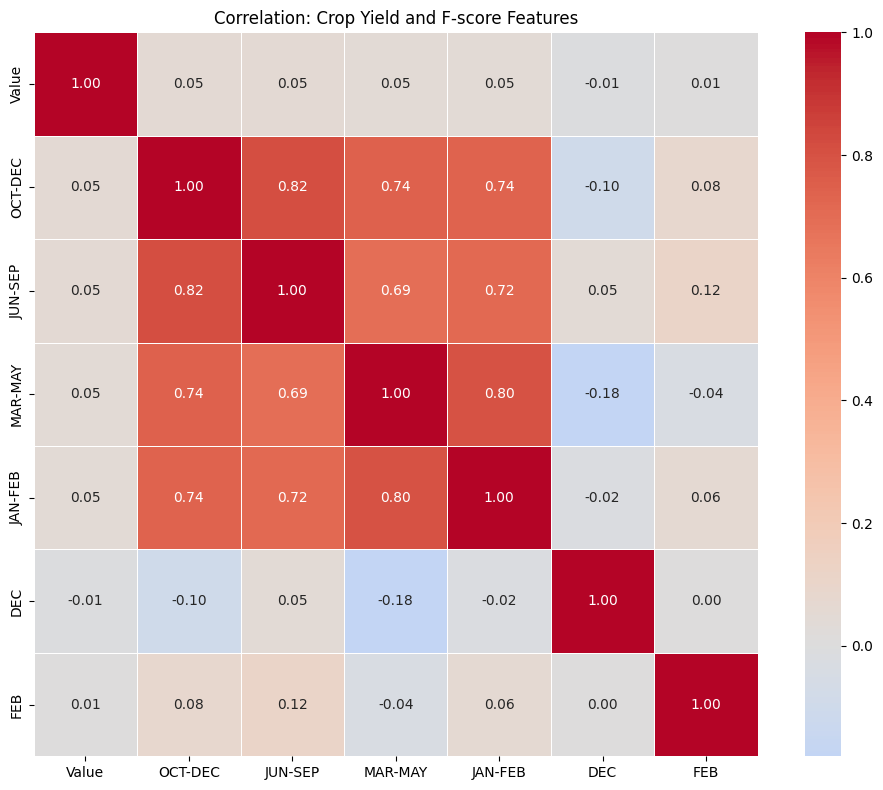

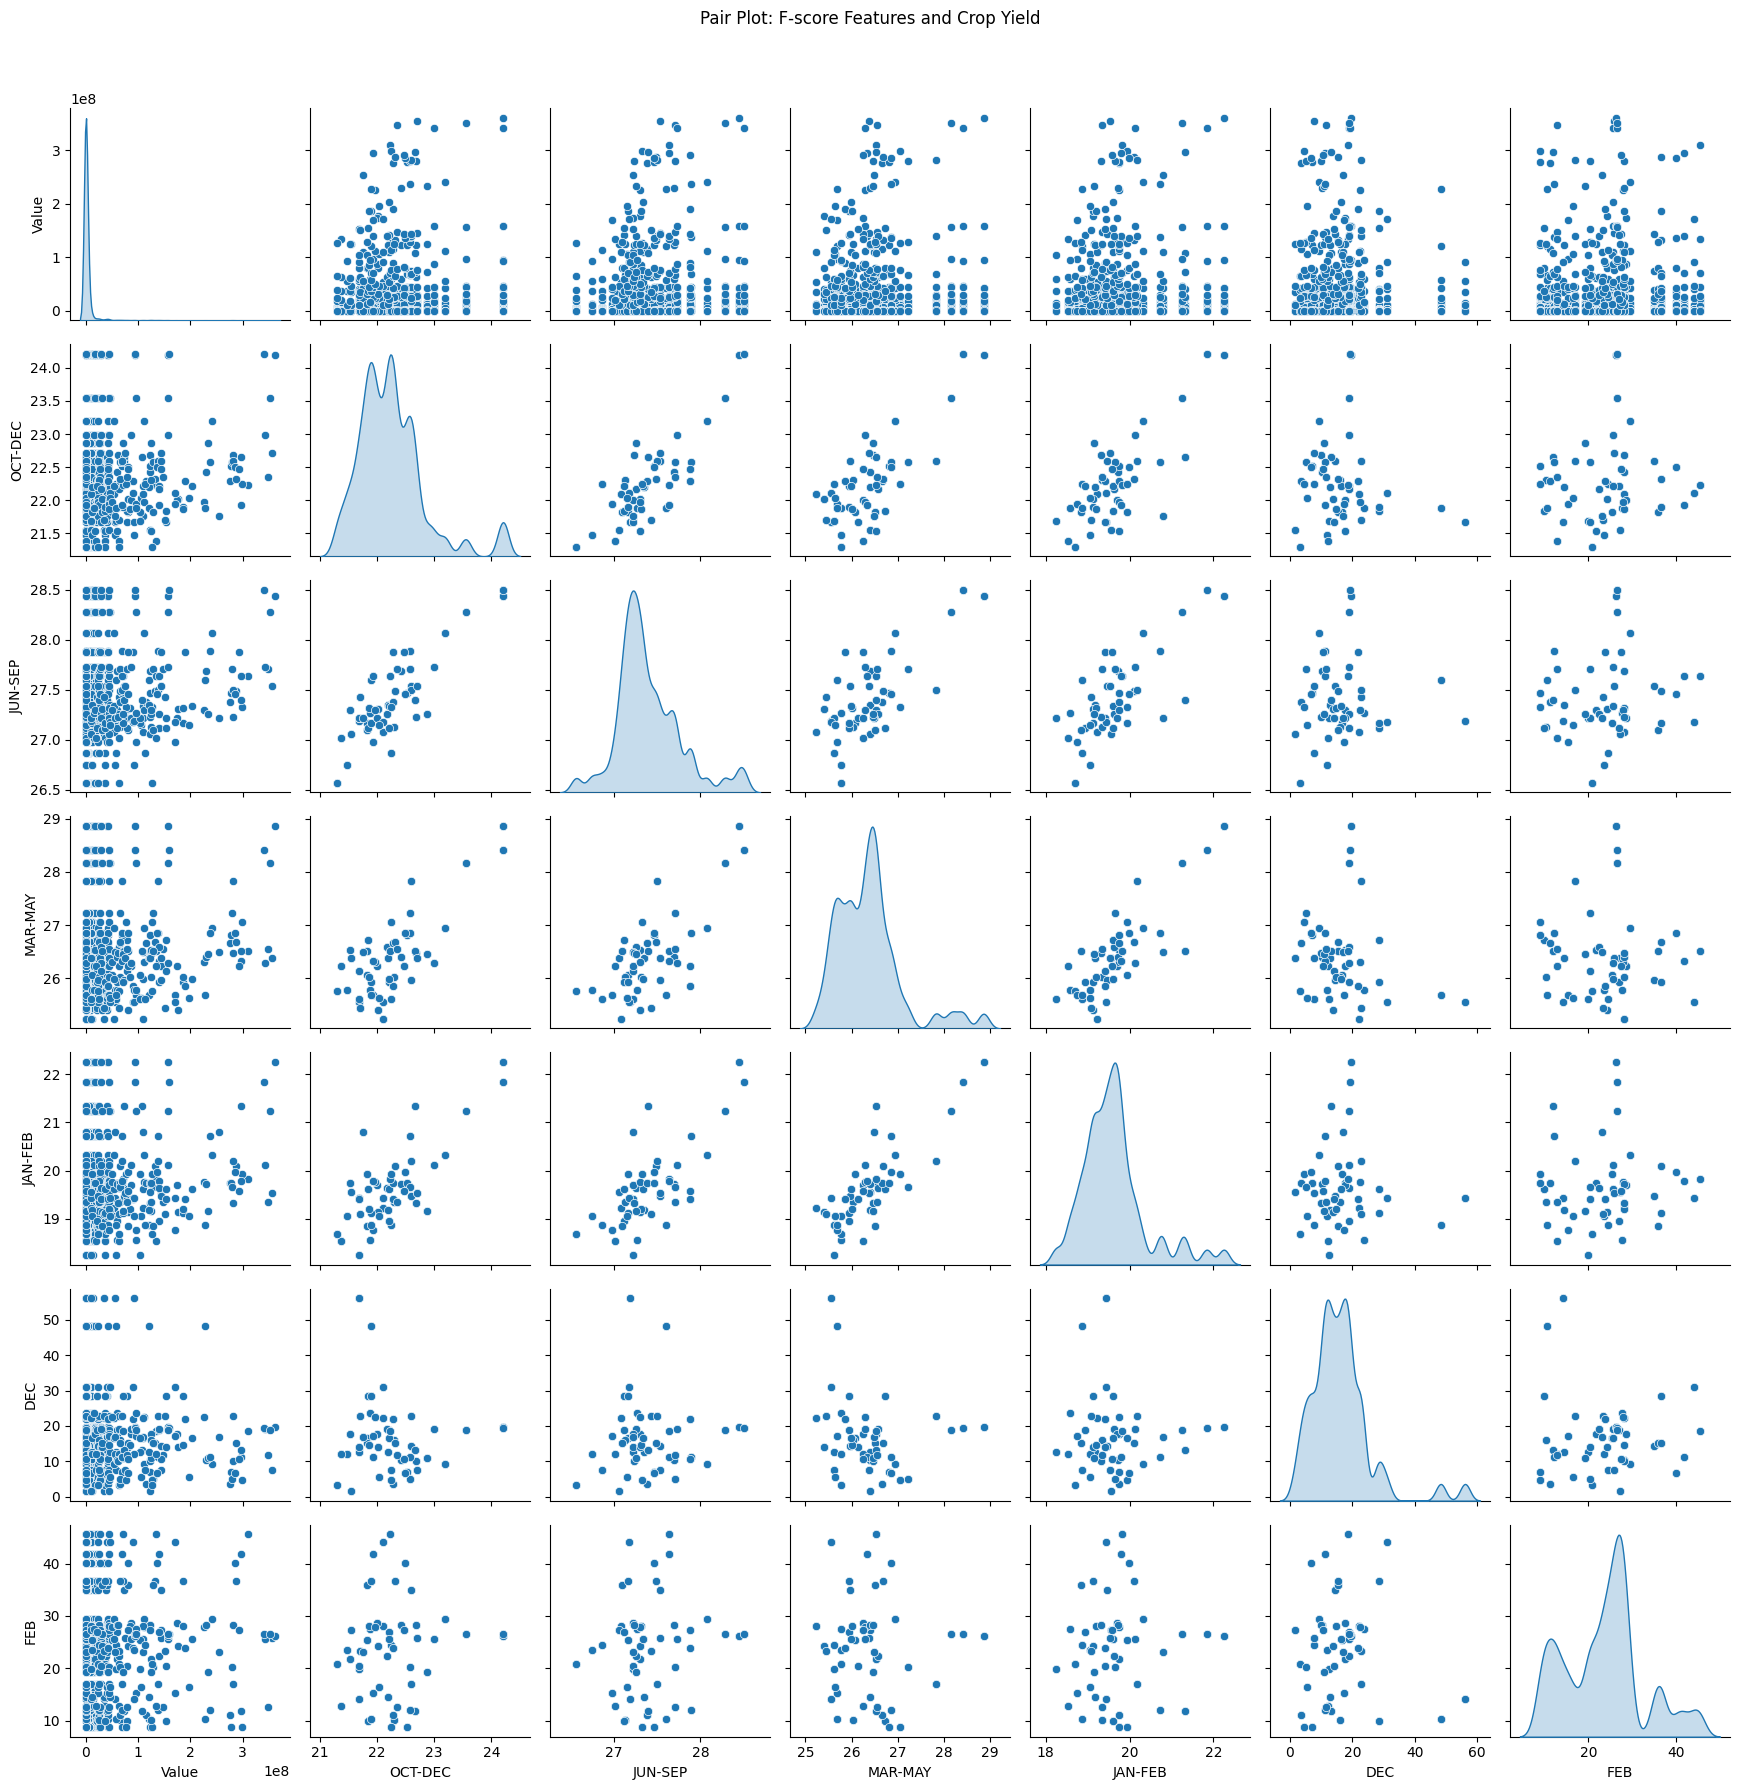


FEATURE DISTRIBUTION ANALYSIS


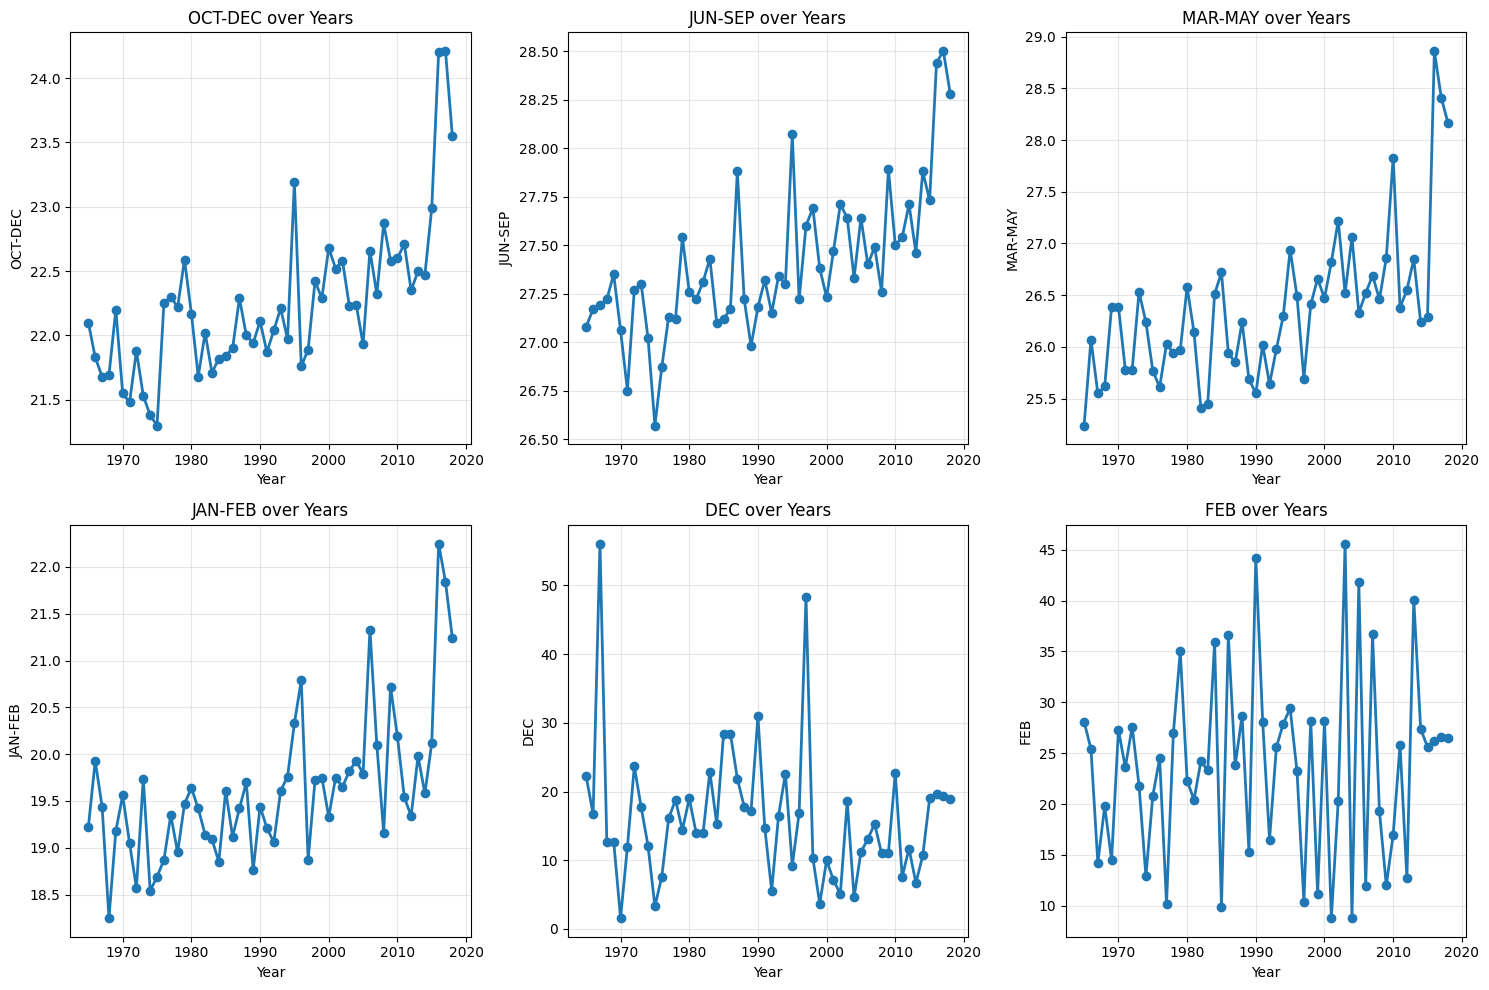


CROP-SPECIFIC FEATURE ANALYSIS

CROP: APPLES
Number of samples: 162
Yield range: 21700.00 - 2891000.00
Average yield: 413329.67

Correlation with yield for this crop:
Value      1.000000
OCT-DEC    0.315915
JUN-SEP    0.306780
MAR-MAY    0.268529
JAN-FEB    0.267075
FEB        0.053033
DEC       -0.034700
Name: Value, dtype: float64

CROP: APRICOTS
Number of samples: 162
Yield range: 1500.00 - 32500.00
Average yield: 13854.23

Correlation with yield for this crop:
Value      1.000000
MAR-MAY    0.044485
OCT-DEC    0.038048
JAN-FEB    0.029000
JUN-SEP    0.027790
FEB       -0.003309
DEC       -0.018940
Name: Value, dtype: float64

CROP: ARECA NUTS
Number of samples: 162
Yield range: 8288.00 - 681000.00
Average yield: 174802.51

Correlation with yield for this crop:
Value      1.000000
OCT-DEC    0.417059
MAR-MAY    0.391760
JUN-SEP    0.391384
JAN-FEB    0.365899
FEB        0.031714
DEC       -0.072952
Name: Value, dtype: float64

CROP: BANANAS
Number of samples: 162
Yield range: 11979

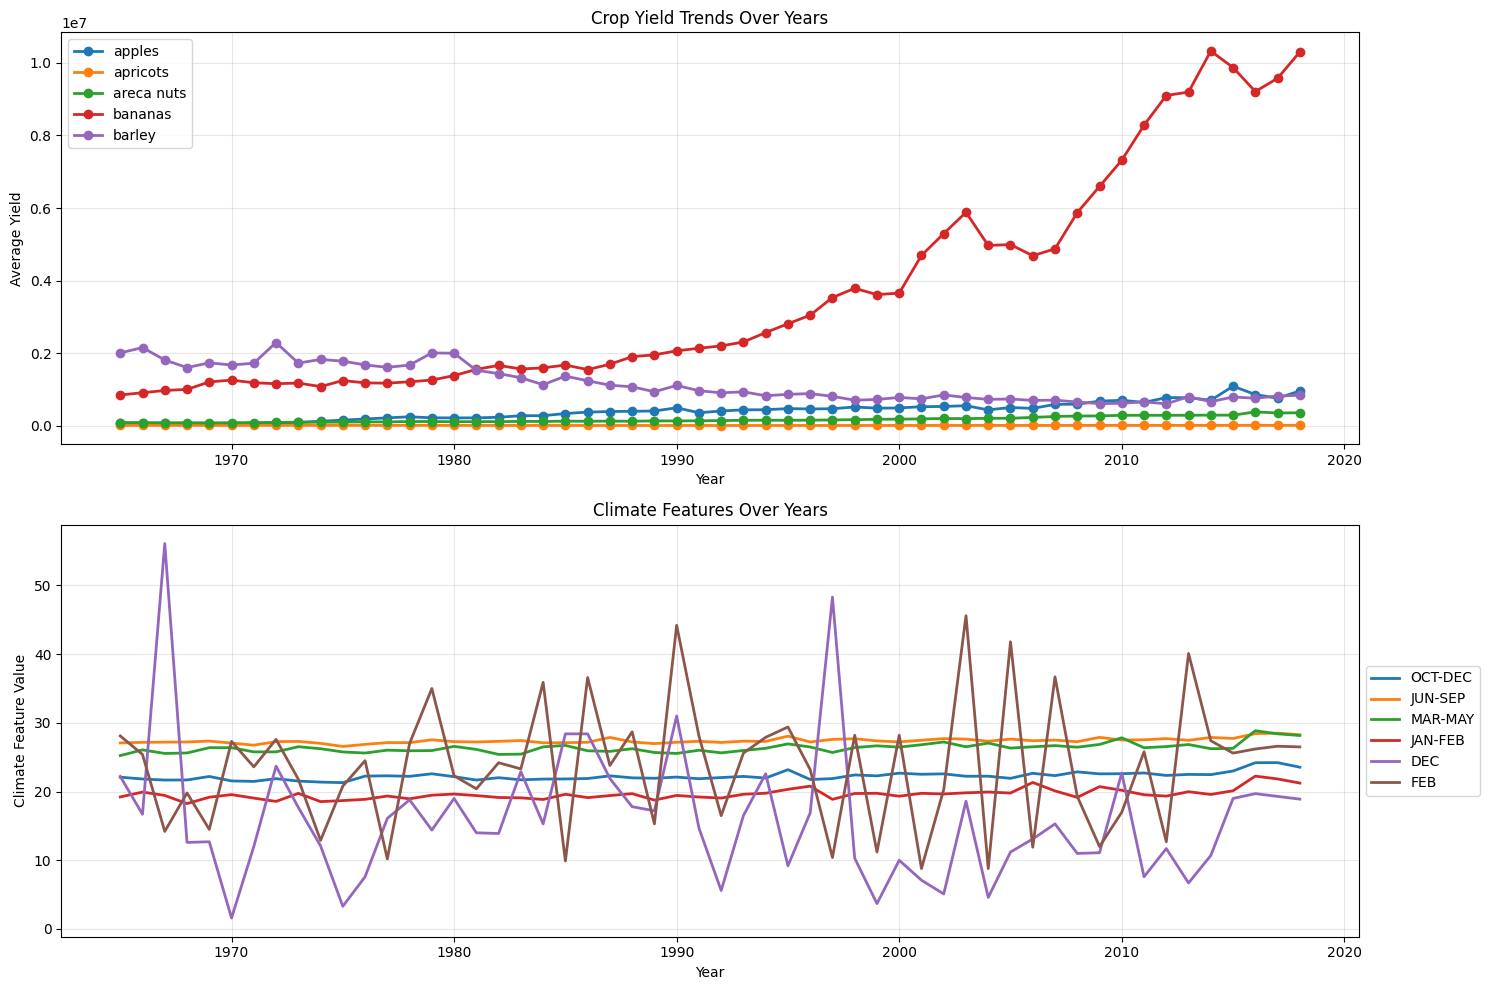


SUMMARY STATISTICS

MERGED DATASET SUMMARY:
----------------------
Total samples: 7938
Number of crops: 49
Years covered: 1965 - 2018
F-score features: ['OCT-DEC', 'JUN-SEP', 'MAR-MAY', 'JAN-FEB', 'DEC', 'FEB']

CROP COVERAGE:
--------------
crop_type
apples         162
apricots       162
areca nuts     162
bananas        162
barley         162
beans dry      162
beans green    162
cabbage        162
carrots        162
cashewnuts     162
Name: count, dtype: int64

DATA FILES CREATED:
-------------------
1. crop_fscore_merged_data.csv - Main merged dataset
2. crop_fscore_merged_complete.csv - Complete merged data
3. crop_fscore_aggregated.csv - Aggregated by crop-year
4. crop_fscore_wide_format.csv - Wide format (crops as columns)

FEATURE CORRELATION WITH YIELD:
------------------------------
Value      1.000000
JUN-SEP    0.052601
OCT-DEC    0.052531
MAR-MAY    0.048746
JAN-FEB    0.046767
FEB        0.005250
DEC       -0.012035


✅ Merging completed successfully!


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===================== 1. LOAD AND PREPARE DATA =====================

# F-score selected features (from your output)
fscore_selected_features = ['OCT-DEC', 'JUN-SEP', 'MAR-MAY', 'JAN-FEB', 'DEC', 'FEB']
print(f"F-score selected features: {fscore_selected_features}")

# Load climate data with selected features
# climate_fscore = climate_df_clean[['Year'] + fscore_selected_features].copy()

climate_fscore = climate_df_clean[['Year'] + final_selected_features].copy()


print("\nClimate data with F-score selected features:")
print(climate_fscore.head())
print(f"Shape: {climate_fscore.shape}")

# Load crop data
crop_data_clean = crop_df.copy()
crop_data_clean = crop_data_clean[['Year', 'Item', 'Value', 'crop_type', 'Nitrogen (N) kg/ha', 'Phosphorus (P) kg/ha', 'Potassium (K) kg/ha' ]].dropna()
crop_data_clean['Year'] = crop_data_clean['Year'].astype(int)

print("\nCrop data:")
print(crop_data_clean.head())
print(f"Shape: {crop_data_clean.shape}")

# ===================== 2. MERGE CROP DATA WITH F-SCORE FEATURES =====================

# Merge crop data with F-score selected climate features
merged_fscore_data = pd.merge(
    crop_data_clean,
    climate_fscore,
    on='Year',
    how='inner'
)

print("\nMerged dataset (crop + F-score selected features):")
print(merged_fscore_data.head())
print(f"Shape: {merged_fscore_data.shape}")
print(f"Columns: {merged_fscore_data.columns.tolist()}")

# ===================== 3. SAVE MERGED DATASET =====================

# Save the merged dataset
merged_fscore_data.to_csv('crop_fscore_merged_data.csv', index=False)
print("\n✅ Merged dataset saved to 'crop_fscore_merged_data.csv'")

# ===================== 4. EXPLORE MERGED DATA =====================

print("\n" + "="*60)
print("EXPLORATORY ANALYSIS OF MERGED DATA")
print("="*60)

# Summary statistics
print("\nBasic statistics of merged data:")
print(merged_fscore_data.describe())

# Check for missing values
print("\nMissing values in merged dataset:")
print(merged_fscore_data.isnull().sum())

# Summary by crop
print("\nCrop types in dataset:")
print(merged_fscore_data.groupby('crop_type').agg({
    'Value': ['count', 'mean', 'std', 'min', 'max'],
    'Year': ['min', 'max']
}))

# ===================== 5. CORRELATION ANALYSIS =====================

print("\n" + "="*60)
print("CORRELATION ANALYSIS WITH F-SCORE FEATURES")
print("="*60)

# Correlation between F-score features and crop yield
correlation_matrix = merged_fscore_data[['Value'] + fscore_selected_features].corr()
print("\nCorrelation with crop yield (Value):")
print(correlation_matrix['Value'].sort_values(ascending=False))

# Visualize correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation: Crop Yield and F-score Features')
plt.tight_layout()
plt.show()

# Pair plot of selected features
sns.pairplot(merged_fscore_data[['Value'] + fscore_selected_features],
             diag_kind='kde', height=2.5)
plt.suptitle('Pair Plot: F-score Features and Crop Yield', y=1.02)
plt.tight_layout()
plt.show()

# ===================== 6. FEATURE DISTRIBUTION ANALYSIS =====================

print("\n" + "="*60)
print("FEATURE DISTRIBUTION ANALYSIS")
print("="*60)

# Distribution of F-score features over years
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(fscore_selected_features):
    axes[i].plot(merged_fscore_data.groupby('Year')[feature].mean(),
                 marker='o', linewidth=2)
    axes[i].set_title(f'{feature} over Years')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel(feature)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===================== 7. CROP-SPECIFIC FEATURE ANALYSIS =====================

print("\n" + "="*60)
print("CROP-SPECIFIC FEATURE ANALYSIS")
print("="*60)

# Select top 5 crops for detailed analysis
top_crops = merged_fscore_data.groupby('crop_type')['Value'].count().sort_values(ascending=False).head(5).index

for crop in top_crops:
    print(f"\n{'='*40}")
    print(f"CROP: {crop.upper()}")
    print('='*40)

    crop_data = merged_fscore_data[merged_fscore_data['crop_type'] == crop]
    print(f"Number of samples: {len(crop_data)}")
    print(f"Yield range: {crop_data['Value'].min():.2f} - {crop_data['Value'].max():.2f}")
    print(f"Average yield: {crop_data['Value'].mean():.2f}")

    # Correlation for this crop
    crop_corr = crop_data[['Value'] + fscore_selected_features].corr()['Value']
    print("\nCorrelation with yield for this crop:")
    print(crop_corr.sort_values(ascending=False))

# ===================== 8. CREATE FINAL DATASET =====================

print("\n" + "="*60)
print("CREATE FINAL DATASETS")
print("="*60)

# Dataset 1: All merged data
final_dataset_1 = merged_fscore_data.copy()

# Dataset 2: Aggregated by crop and year (average yield per crop-year)
final_dataset_2 = merged_fscore_data.groupby(['Year', 'crop_type']).agg({
    'Value': 'mean',
    'OCT-DEC': 'first',
    'JUN-SEP': 'first',
    'MAR-MAY': 'first',
    'JAN-FEB': 'first',
    'DEC': 'first',
    'FEB': 'first'
}).reset_index()

# Dataset 3: Wide format (each crop as separate column)
final_dataset_3 = merged_fscore_data.pivot_table(
    index='Year',
    columns='crop_type',
    values='Value',
    aggfunc='mean'
).reset_index()

# Save all datasets
final_dataset_1.to_csv('crop_fscore_merged_complete.csv', index=False)
final_dataset_2.to_csv('crop_fscore_aggregated.csv', index=False)
final_dataset_3.to_csv('crop_fscore_wide_format.csv', index=False)

print("\n✅ Datasets saved:")
print(f"1. crop_fscore_merged_complete.csv - Complete merged data ({final_dataset_1.shape})")
print(f"2. crop_fscore_aggregated.csv - Aggregated by crop-year ({final_dataset_2.shape})")
print(f"3. crop_fscore_wide_format.csv - Wide format ({final_dataset_3.shape})")

# ===================== 9. VISUALIZATION OF CROP YIELD TRENDS =====================

# Plot crop yield trends with climate features
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Crop yield trends for top crops
ax1 = axes[0]
for crop in top_crops[:5]:
    crop_data = merged_fscore_data[merged_fscore_data['crop_type'] == crop]
    crop_yearly = crop_data.groupby('Year')['Value'].mean()
    ax1.plot(crop_yearly.index, crop_yearly.values, label=crop, marker='o', linewidth=2)

ax1.set_xlabel('Year')
ax1.set_ylabel('Average Yield')
ax1.set_title('Crop Yield Trends Over Years')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Climate features over years
ax2 = axes[1]
for feature in fscore_selected_features:
    feature_yearly = merged_fscore_data.groupby('Year')[feature].mean()
    ax2.plot(feature_yearly.index, feature_yearly.values, label=feature, linewidth=2)

ax2.set_xlabel('Year')
ax2.set_ylabel('Climate Feature Value')
ax2.set_title('Climate Features Over Years')
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===================== 10. SUMMARY STATISTICS =====================

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

print(f"""
MERGED DATASET SUMMARY:
----------------------
Total samples: {len(merged_fscore_data)}
Number of crops: {merged_fscore_data['crop_type'].nunique()}
Years covered: {merged_fscore_data['Year'].min()} - {merged_fscore_data['Year'].max()}
F-score features: {fscore_selected_features}

CROP COVERAGE:
--------------
{merged_fscore_data['crop_type'].value_counts().head(10)}

DATA FILES CREATED:
-------------------
1. crop_fscore_merged_data.csv - Main merged dataset
2. crop_fscore_merged_complete.csv - Complete merged data
3. crop_fscore_aggregated.csv - Aggregated by crop-year
4. crop_fscore_wide_format.csv - Wide format (crops as columns)

FEATURE CORRELATION WITH YIELD:
------------------------------
{merged_fscore_data[['Value'] + fscore_selected_features].corr()['Value'].sort_values(ascending=False).to_string()}
""")

print("\n✅ Merging completed successfully!")

#Clustering

In [39]:
# ===================== 1. LOAD MERGED DATASET =====================

# Load the merged dataset (crop + F-score features)
merged_data = pd.read_csv('crop_fscore_merged_data.csv')

print("="*60)
print("LOADED MERGED DATASET")
print("="*60)
print(f"Dataset shape: {merged_data.shape}")
print(f"Columns: {merged_data.columns.tolist()}")
print("\nFirst 5 rows:")
print(merged_data.head())

# ===================== 2. PREPARE DATA FOR CLUSTERING =====================

# Select features for clustering (F-score selected features)
fscore_features = ['OCT-DEC', 'JUN-SEP', 'MAR-MAY', 'JAN-FEB', 'DEC', 'FEB']
print(f"\nFeatures used for clustering: {fscore_features}")

# Extract feature matrix
X = merged_data[fscore_features].copy()

# Handle missing values
X = X.fillna(X.mean())

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=fscore_features)

print(f"\nFeature matrix shape: {X_scaled_df.shape}")
print("Feature statistics after scaling:")
print(X_scaled_df.describe())

LOADED MERGED DATASET
Dataset shape: (7938, 28)
Columns: ['Year', 'Item', 'Value', 'crop_type', 'Nitrogen (N) kg/ha', 'Phosphorus (P) kg/ha', 'Potassium (K) kg/ha', 'SEP', 'MAR-MAY', 'Jan-Feb', 'JUN', 'Oct-Dec', 'MAR', 'Mar-May', 'JAN-FEB', 'OCT-DEC', 'DEC', 'APR', 'JAN', 'MAY', 'JUN-SEP', 'AUG', 'FEB', 'OCT', 'JUL', 'monsoon_avg', 'winter_avg', 'NOV']

First 5 rows:
   Year    Item  Value crop_type  Nitrogen (N) kg/ha  Phosphorus (P) kg/ha  \
0  1965  Apples  44500    apples               92.44                 55.16   
1  1966  Apples  38500    apples              173.10                 22.21   
2  1967  Apples  33700    apples              142.48                 58.37   
3  1968  Apples  26500    apples              123.81                 37.07   
4  1969  Apples  21700    apples               61.84                 75.57   

   Potassium (K) kg/ha    SEP  MAR-MAY  Jan-Feb  ...   JAN   MAY  JUN-SEP  \
0                43.72  129.5    25.24     39.9  ...  11.8  52.7    27.08   
1      


DETERMINING OPTIMAL NUMBER OF CLUSTERS


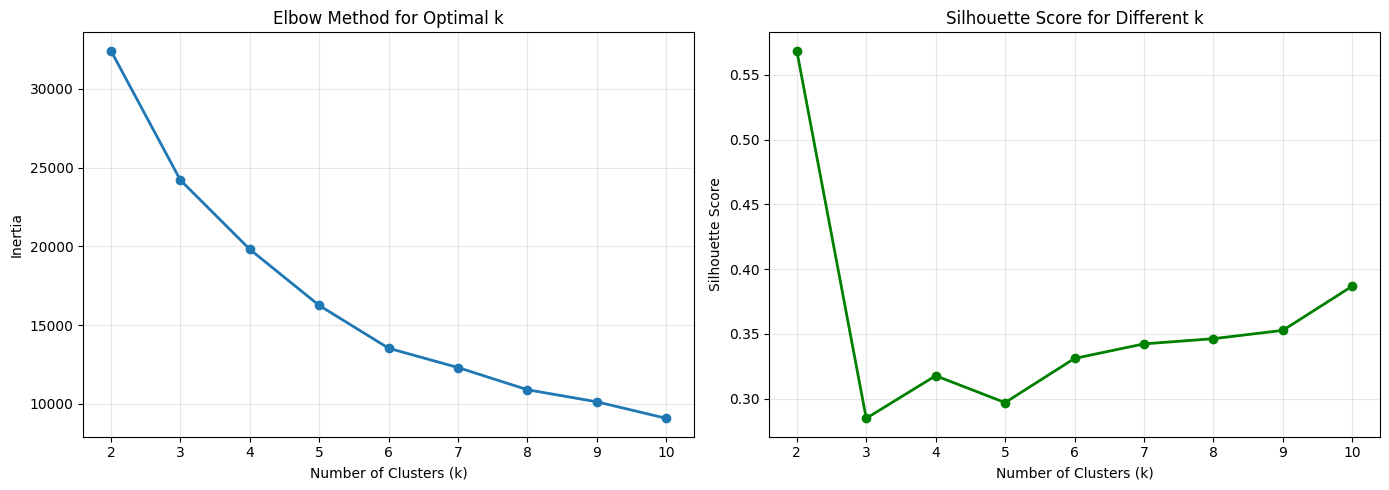

In [40]:
# ===================== 3. DETERMINE OPTIMAL NUMBER OF CLUSTERS (ELBOW METHOD) =====================

print("\n" + "="*60)
print("DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print("="*60)

# Elbow method
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia, marker='o', linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, marker='o', color='green', linewidth=2)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Different k')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




DETERMINING OPTIMAL NUMBER OF CLUSTERS


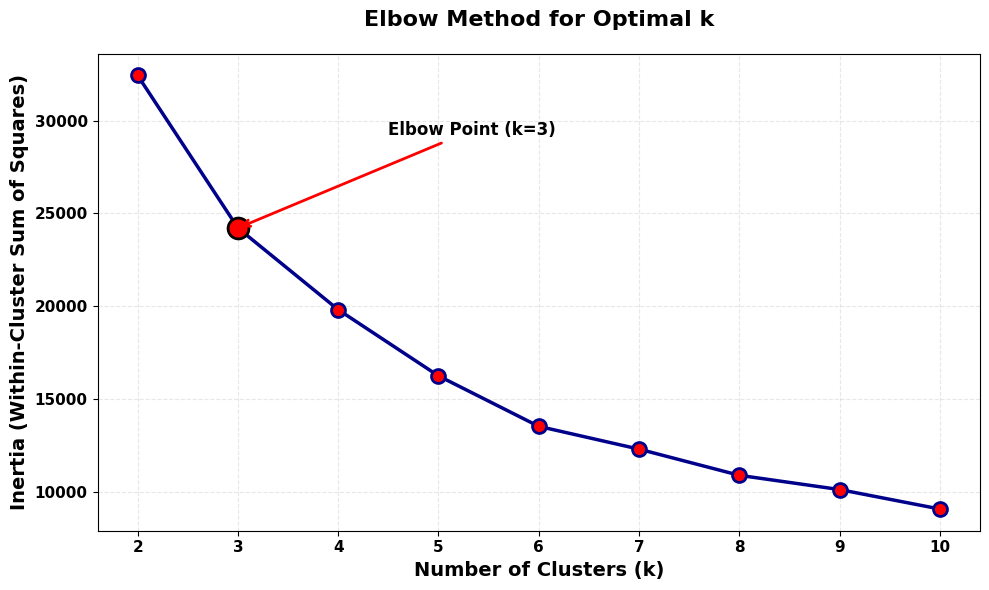


ELBOW METHOD RESULTS
  k=2: Inertia = 32,431
  k=3: Inertia = 24,212
  k=4: Inertia = 19,812
  k=5: Inertia = 16,245
  k=6: Inertia = 13,527
  k=7: Inertia = 12,299
  k=8: Inertia = 10,889
  k=9: Inertia = 10,122
  k=10: Inertia = 9,072

    → Elbow point detected at: k = 3


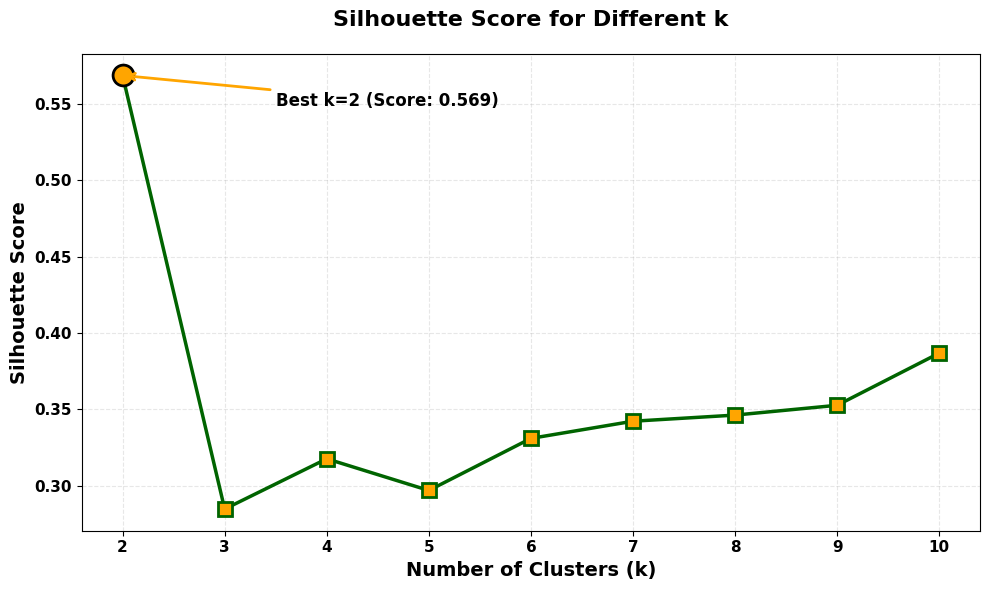


SILHOUETTE SCORE RESULTS
  k=2: Silhouette Score = 0.5686
  k=3: Silhouette Score = 0.2847
  k=4: Silhouette Score = 0.3176
  k=5: Silhouette Score = 0.2969
  k=6: Silhouette Score = 0.3310
  k=7: Silhouette Score = 0.3422
  k=8: Silhouette Score = 0.3462
  k=9: Silhouette Score = 0.3526
  k=10: Silhouette Score = 0.3868

    → Best silhouette score: k=2 (Score: 0.5686)


In [41]:
# ===================== 3. DETERMINE OPTIMAL NUMBER OF CLUSTERS (ELBOW METHOD) =====================

print("\n" + "="*60)
print("DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print("="*60)

# Elbow method
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# ===================== PLOT 1: ELBOW METHOD (SEPARATE) =====================
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linewidth=2.5, markersize=10,
         color='darkblue', markerfacecolor='red', markeredgewidth=2)

# Highlight the elbow point (k=3)
elbow_k = 3
elbow_idx = list(K_range).index(elbow_k)
plt.plot(elbow_k, inertia[elbow_idx], 'o', color='red', markersize=15,
         markerfacecolor='red', markeredgecolor='black', markeredgewidth=2)

# Add annotation for elbow point
plt.annotate(f'Elbow Point (k={elbow_k})',
             xy=(elbow_k, inertia[elbow_idx]),
             xytext=(elbow_k + 1.5, inertia[elbow_idx] + 5000),
             fontsize=12, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='red', lw=2))

plt.xlabel('Number of Clusters (k)', fontsize=14, fontweight='bold')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=14, fontweight='bold')
plt.title('Elbow Method for Optimal k', fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Print elbow results
print("\n" + "="*60)
print("ELBOW METHOD RESULTS")
print("="*60)
for k, iner in zip(K_range, inertia):
    print(f"  k={k}: Inertia = {iner:,.0f}")
print(f"\n{' '*4}→ Elbow point detected at: k = {elbow_k}")

# ===================== PLOT 2: SILHOUETTE SCORE (SEPARATE) =====================
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='s', linewidth=2.5, markersize=10,
         color='darkgreen', markerfacecolor='orange', markeredgewidth=2)

# Highlight the best silhouette score
best_k = K_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
best_idx = list(K_range).index(best_k)
plt.plot(best_k, best_score, 'o', color='orange', markersize=15,
         markerfacecolor='orange', markeredgecolor='black', markeredgewidth=2)

# Add annotation for best silhouette score
plt.annotate(f'Best k={best_k} (Score: {best_score:.3f})',
             xy=(best_k, best_score),
             xytext=(best_k + 1.5, best_score - 0.02),
             fontsize=12, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='orange', lw=2))

plt.xlabel('Number of Clusters (k)', fontsize=14, fontweight='bold')
plt.ylabel('Silhouette Score', fontsize=14, fontweight='bold')
plt.title('Silhouette Score for Different k', fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Print silhouette results
print("\n" + "="*60)
print("SILHOUETTE SCORE RESULTS")
print("="*60)
for k, score in zip(K_range, silhouette_scores):
    print(f"  k={k}: Silhouette Score = {score:.4f}")
print(f"\n{' '*4}→ Best silhouette score: k={best_k} (Score: {best_score:.4f})")

In [42]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')

In [43]:
# ===================== 4. METHOD 1: K-MEANS CLUSTERING =====================

print("\n" + "="*60)
print("METHOD 1: K-MEANS CLUSTERING")
print("="*60)

# Apply K-Means with optimal k
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to original data
merged_data['KMeans_Cluster'] = kmeans_labels

# Evaluate K-Means
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_calinski = calinski_harabasz_score(X_scaled, kmeans_labels)
kmeans_davies = davies_bouldin_score(X_scaled, kmeans_labels)

print(f"K-Means Evaluation Metrics:")
print(f"  - Silhouette Score: {kmeans_silhouette:.4f}")
print(f"  - Calinski-Harabasz Score: {kmeans_calinski:.4f}")
print(f"  - Davies-Bouldin Score: {kmeans_davies:.4f}")
print(f"\nCluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

# Cluster centers
print("\nCluster Centers (scaled features):")
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=fscore_features
)
print(cluster_centers)


METHOD 1: K-MEANS CLUSTERING
K-Means Evaluation Metrics:
  - Silhouette Score: 0.5686
  - Calinski-Harabasz Score: 3718.8568
  - Davies-Bouldin Score: 0.4563

Cluster sizes:
0    7497
1     441
Name: count, dtype: int64

Cluster Centers (scaled features):
    OCT-DEC   JUN-SEP   MAR-MAY   JAN-FEB       DEC       FEB
0 -0.173932 -0.157664 -0.173094 -0.163837 -0.019614 -0.017835
1  2.956844  2.680294  2.942594  2.785231  0.333444  0.303189



METHOD 2: DBSCAN CLUSTERING


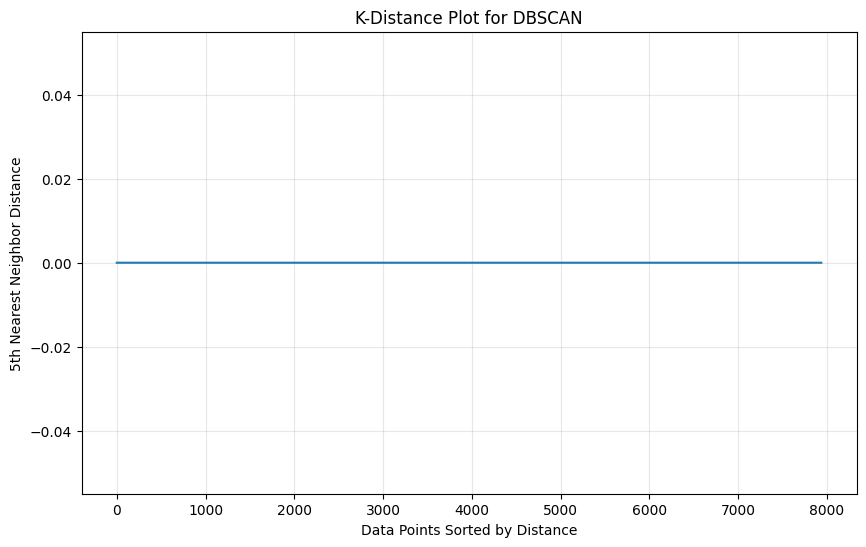

Testing DBSCAN with different parameters:
  eps=0.5, min_samples=3: clusters=54, noise=0, silhouette=1.0000
  eps=0.5, min_samples=5: clusters=54, noise=0, silhouette=1.0000
  eps=0.5, min_samples=7: clusters=54, noise=0, silhouette=1.0000
  eps=0.5, min_samples=10: clusters=54, noise=0, silhouette=1.0000
  eps=0.8, min_samples=3: clusters=47, noise=0, silhouette=0.9056
  eps=0.8, min_samples=5: clusters=47, noise=0, silhouette=0.9056
  eps=0.8, min_samples=7: clusters=47, noise=0, silhouette=0.9056
  eps=0.8, min_samples=10: clusters=47, noise=0, silhouette=0.9056
  eps=1.0, min_samples=3: clusters=39, noise=0, silhouette=0.7676
  eps=1.0, min_samples=5: clusters=39, noise=0, silhouette=0.7676
  eps=1.0, min_samples=7: clusters=39, noise=0, silhouette=0.7676
  eps=1.0, min_samples=10: clusters=39, noise=0, silhouette=0.7676
  eps=1.2, min_samples=3: clusters=29, noise=0, silhouette=0.5972
  eps=1.2, min_samples=5: clusters=29, noise=0, silhouette=0.5972
  eps=1.2, min_samples=7: clust

In [44]:
# ===================== 5. METHOD 2: DBSCAN CLUSTERING =====================

print("\n" + "="*60)
print("METHOD 2: DBSCAN CLUSTERING")
print("="*60)

# Find optimal eps using k-distance plot
from sklearn.neighbors import NearestNeighbors

# Compute k-distance
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4])  # 5th nearest neighbor

# Plot k-distance
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Data Points Sorted by Distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('K-Distance Plot for DBSCAN')
plt.grid(True, alpha=0.3)
plt.show()

# Try different eps values
eps_values = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
min_samples_values = [3, 5, 7, 10]

best_dbscan_score = -1
best_dbscan_params = None
best_dbscan_labels = None

print("Testing DBSCAN with different parameters:")
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters > 1:  # Need at least 2 clusters for silhouette score
            try:
                score = silhouette_score(X_scaled, labels)
                if score > best_dbscan_score:
                    best_dbscan_score = score
                    best_dbscan_params = (eps, min_samples)
                    best_dbscan_labels = labels
                print(f"  eps={eps}, min_samples={min_samples}: clusters={n_clusters}, noise={n_noise}, silhouette={score:.4f}")
            except:
                print(f"  eps={eps}, min_samples={min_samples}: clusters={n_clusters}, noise={n_noise} - Cannot compute silhouette")
        else:
            print(f"  eps={eps}, min_samples={min_samples}: clusters={n_clusters}, noise={n_noise}")

if best_dbscan_labels is not None:
    merged_data['DBSCAN_Cluster'] = best_dbscan_labels
    print(f"\nBest DBSCAN parameters: eps={best_dbscan_params[0]}, min_samples={best_dbscan_params[1]}")
    print(f"Best Silhouette Score: {best_dbscan_score:.4f}")
    print(f"Number of clusters: {len(set(best_dbscan_labels)) - (1 if -1 in best_dbscan_labels else 0)}")
    print(f"Number of noise points: {list(best_dbscan_labels).count(-1)}")
    print(f"Cluster sizes:")
    print(pd.Series(best_dbscan_labels).value_counts().sort_index())
else:
    print("\nNo suitable DBSCAN clustering found with silhouette score > 0")
    # Use default DBSCAN
    dbscan = DBSCAN(eps=1.0, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X_scaled)
    merged_data['DBSCAN_Cluster'] = dbscan_labels
    print("Using default DBSCAN (eps=1.0, min_samples=5)")

In [45]:
# ===================== 6. METHOD 3: HIERARCHICAL CLUSTERING =====================

print("\n" + "="*60)
print("METHOD 3: HIERARCHICAL CLUSTERING")
print("="*60)

# Try different linkage methods and number of clusters
linkage_methods = ['ward', 'complete', 'average', 'single']
best_hierarchical_score = -1
best_hierarchical_params = None
best_hierarchical_labels = None

print("Testing Hierarchical Clustering with different parameters:")
for method in linkage_methods:
    for n_clusters in range(2, 8):
        hierarchical = AgglomerativeClustering(
            n_clusters=n_clusters,
            linkage=method
        )
        labels = hierarchical.fit_predict(X_scaled)

        try:
            score = silhouette_score(X_scaled, labels)
            if score > best_hierarchical_score:
                best_hierarchical_score = score
                best_hierarchical_params = (method, n_clusters)
                best_hierarchical_labels = labels
            print(f"  method={method}, n_clusters={n_clusters}: silhouette={score:.4f}")
        except:
            print(f"  method={method}, n_clusters={n_clusters}: Cannot compute silhouette")

if best_hierarchical_labels is not None:
    merged_data['Hierarchical_Cluster'] = best_hierarchical_labels
    print(f"\nBest Hierarchical parameters: method={best_hierarchical_params[0]}, n_clusters={best_hierarchical_params[1]}")
    print(f"Best Silhouette Score: {best_hierarchical_score:.4f}")
    print(f"Cluster sizes:")
    print(pd.Series(best_hierarchical_labels).value_counts().sort_index())
else:
    # Use default hierarchical
    hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
    hierarchical_labels = hierarchical.fit_predict(X_scaled)
    merged_data['Hierarchical_Cluster'] = hierarchical_labels
    print("Using default hierarchical (n_clusters=3, linkage='ward')")



METHOD 3: HIERARCHICAL CLUSTERING
Testing Hierarchical Clustering with different parameters:
  method=ward, n_clusters=2: silhouette=0.5686
  method=ward, n_clusters=3: silhouette=0.2863
  method=ward, n_clusters=4: silhouette=0.3203
  method=ward, n_clusters=5: silhouette=0.3369
  method=ward, n_clusters=6: silhouette=0.3208
  method=ward, n_clusters=7: silhouette=0.3246
  method=complete, n_clusters=2: silhouette=0.5686
  method=complete, n_clusters=3: silhouette=0.4687
  method=complete, n_clusters=4: silhouette=0.2718
  method=complete, n_clusters=5: silhouette=0.2968
  method=complete, n_clusters=6: silhouette=0.2835
  method=complete, n_clusters=7: silhouette=0.2882
  method=average, n_clusters=2: silhouette=0.5223
  method=average, n_clusters=3: silhouette=0.4542
  method=average, n_clusters=4: silhouette=0.2844
  method=average, n_clusters=5: silhouette=0.2691
  method=average, n_clusters=6: silhouette=0.2751
  method=average, n_clusters=7: silhouette=0.2890
  method=single, n


HIERARCHICAL CLUSTERING DENDROGRAM


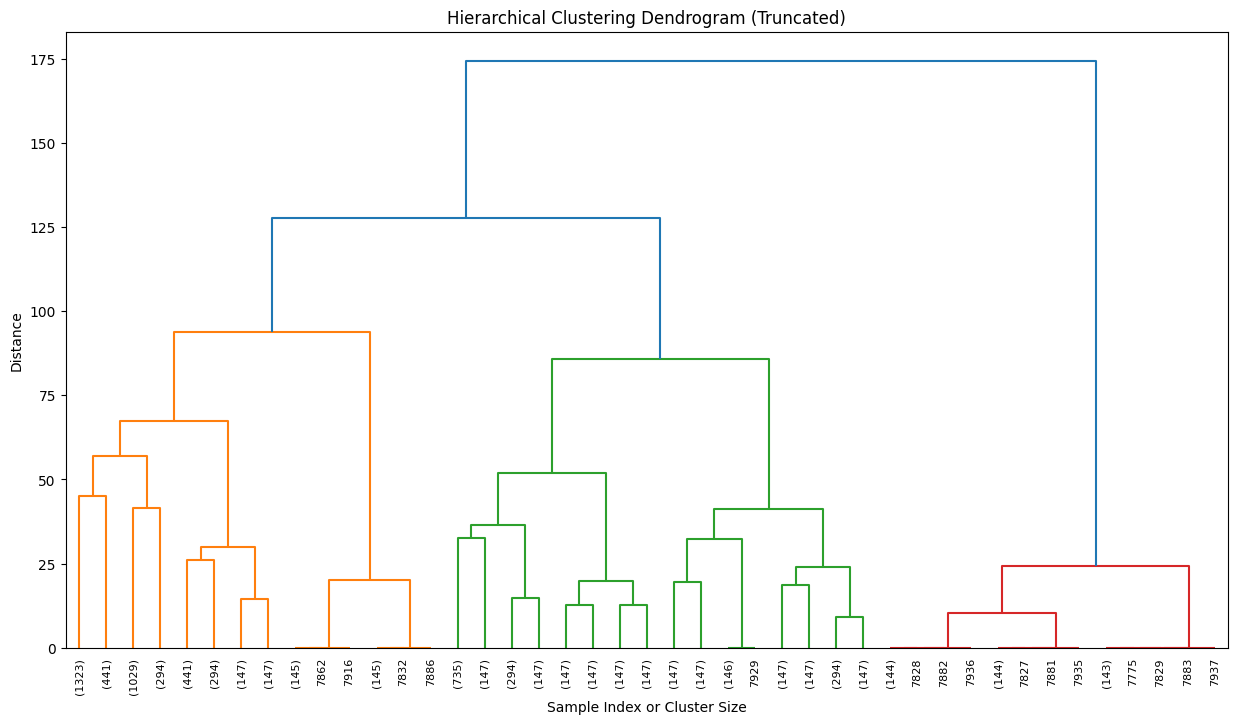

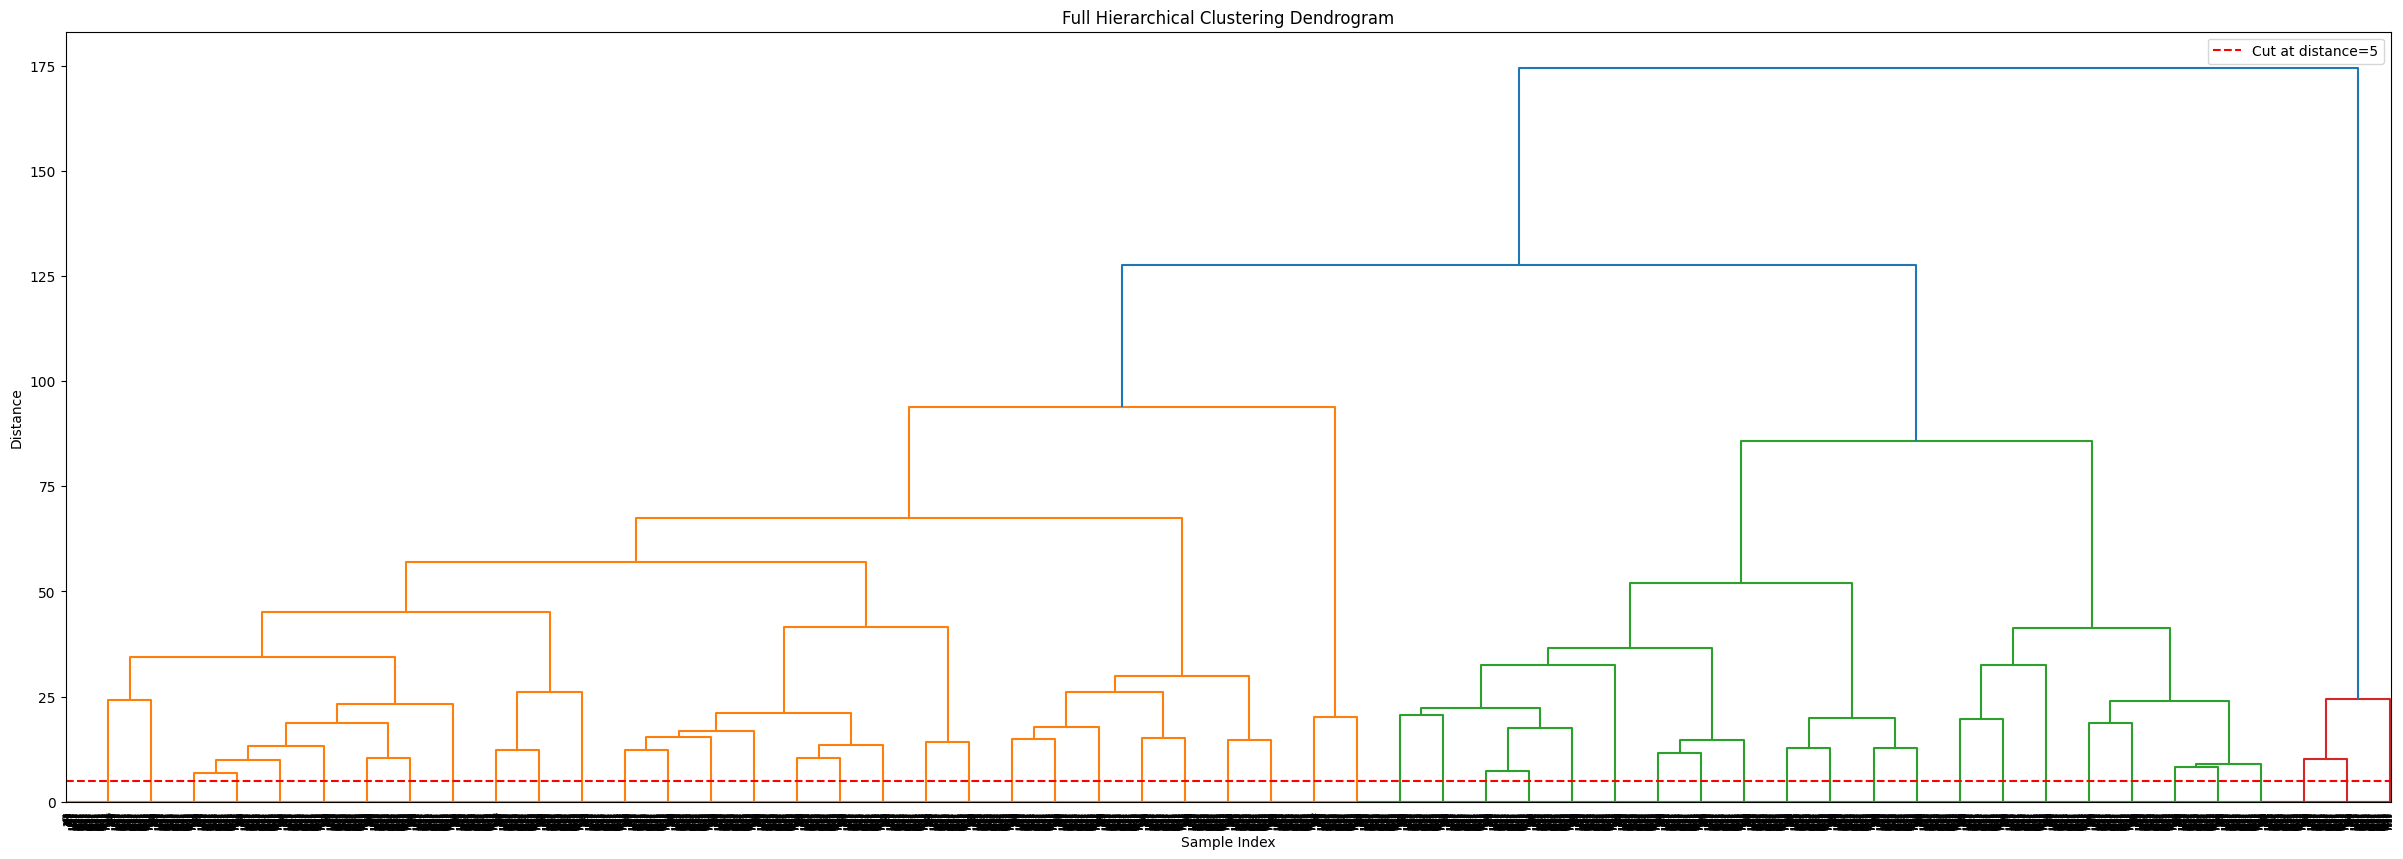

In [46]:
# ===================== 7. DENDROGRAM FOR HIERARCHICAL CLUSTERING =====================

print("\n" + "="*60)
print("HIERARCHICAL CLUSTERING DENDROGRAM")
print("="*60)

# Create linkage matrix
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           truncate_mode='level',
           p=5)
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')
plt.show()

# Full dendrogram
plt.figure(figsize=(30, 10))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False)
plt.title('Full Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.axhline(y=5, color='r', linestyle='--', label='Cut at distance=5')
plt.legend()
plt.show()


COMPARISON OF CLUSTERING METHODS
         Method  Silhouette_Score  N_Clusters  Noise_Points
0       K-Means          0.568602           2             0
1        DBSCAN          1.000000          54             0
2  Hierarchical          0.568602           2             0


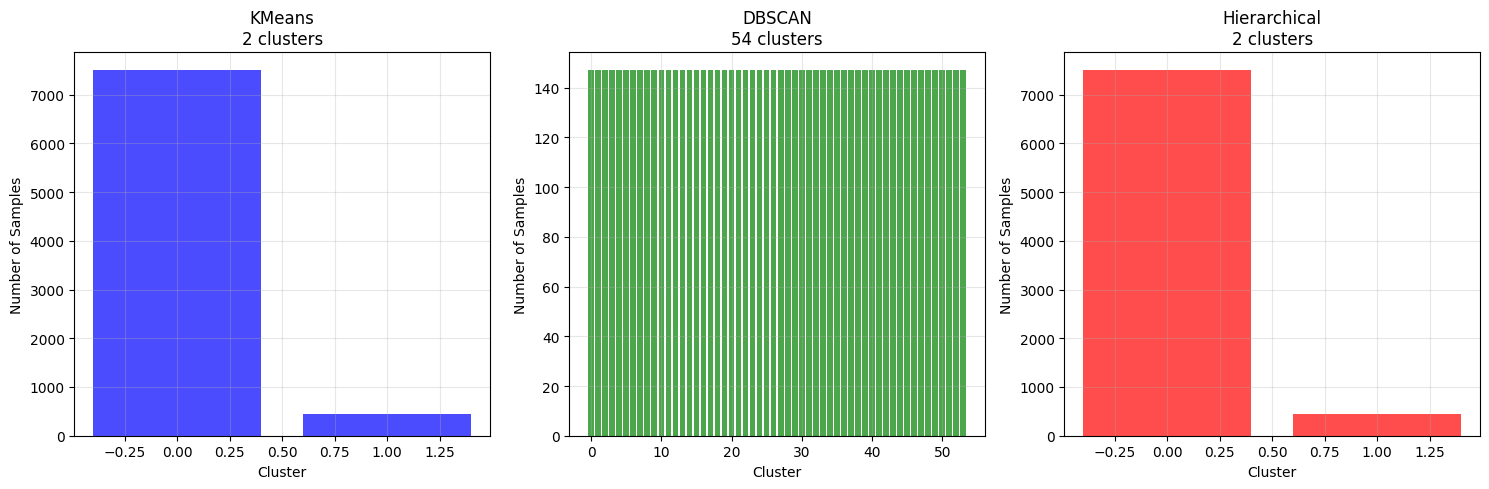

In [47]:
# ===================== 8. COMPARE CLUSTERING METHODS =====================

print("\n" + "="*60)
print("COMPARISON OF CLUSTERING METHODS")
print("="*60)

# Create comparison DataFrame
comparison_data = {
    'Method': ['K-Means', 'DBSCAN', 'Hierarchical'],
    'Silhouette_Score': [
        silhouette_score(X_scaled, merged_data['KMeans_Cluster']),
        silhouette_score(X_scaled, merged_data['DBSCAN_Cluster']) if len(set(merged_data['DBSCAN_Cluster'])) > 1 else np.nan,
        silhouette_score(X_scaled, merged_data['Hierarchical_Cluster'])
    ],
    'N_Clusters': [
        len(set(merged_data['KMeans_Cluster'])),
        len(set(merged_data['DBSCAN_Cluster'])) - (1 if -1 in set(merged_data['DBSCAN_Cluster']) else 0),
        len(set(merged_data['Hierarchical_Cluster']))
    ],
    'Noise_Points': [
        0,
        list(merged_data['DBSCAN_Cluster']).count(-1),
        0
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

methods = ['KMeans', 'DBSCAN', 'Hierarchical']
colors = ['blue', 'green', 'red']

for i, (method, color) in enumerate(zip(methods, colors)):
    # Use the correct column name (KMeans instead of K-Means)
    col_name = f'{method}_Cluster'
    labels = merged_data[col_name]

    if method == 'DBSCAN':
        n_clusters = len(set(labels)) - (1 if -1 in set(labels) else 0)
    else:
        n_clusters = len(set(labels))

    # Bar plot of cluster sizes
    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    axes[i].bar(cluster_sizes.index, cluster_sizes.values, color=color, alpha=0.7)
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Number of Samples')
    axes[i].set_title(f'{method}\n{len(cluster_sizes)} clusters')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


VISUALIZING CLUSTERS USING PCA


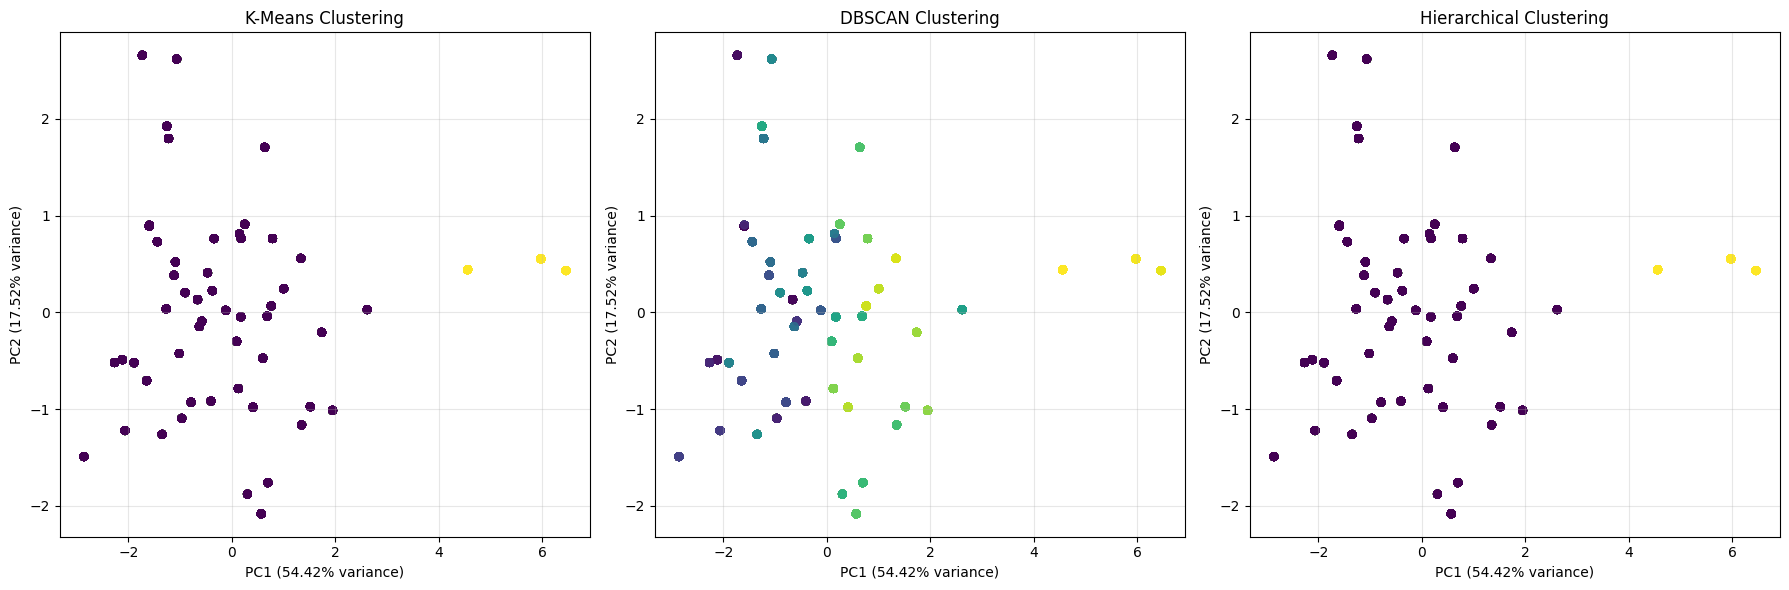

In [48]:
# ===================== 9. VISUALIZE CLUSTERS USING PCA =====================

print("\n" + "="*60)
print("VISUALIZING CLUSTERS USING PCA")
print("="*60)

# Apply PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create subplots for each clustering method
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

methods = ['KMeans_Cluster', 'DBSCAN_Cluster', 'Hierarchical_Cluster']
titles = ['K-Means Clustering', 'DBSCAN Clustering', 'Hierarchical Clustering']

for i, (method, title) in enumerate(zip(methods, titles)):
    # Get cluster labels
    if method == 'DBSCAN_Cluster':
        labels = merged_data[method]
        # Separate noise points
        is_noise = labels == -1
        noise_labels = labels[is_noise]
        cluster_labels = labels[~is_noise]
    else:
        labels = merged_data[method]
        is_noise = np.zeros(len(labels), dtype=bool)

    # Plot
    scatter = axes[i].scatter(X_pca[:, 0], X_pca[:, 1],
                             c=labels, cmap='viridis',
                             alpha=0.7, s=30)

    # Highlight noise points for DBSCAN
    if method == 'DBSCAN_Cluster' and np.any(is_noise):
        axes[i].scatter(X_pca[is_noise, 0], X_pca[is_noise, 1],
                       c='red', marker='x', s=50, label='Noise')

    axes[i].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    axes[i].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    axes[i].set_title(title)
    axes[i].grid(True, alpha=0.3)

    # Add legend for DBSCAN
    if method == 'DBSCAN_Cluster' and np.any(is_noise):
        axes[i].legend()

plt.tight_layout()
plt.show()


In [49]:
# ===================== 10. CLUSTER CHARACTERISTICS =====================

print("\n" + "="*60)
print("CLUSTER CHARACTERISTICS (Using K-Means Results)")
print("="*60)

# Use K-Means clusters for analysis
cluster_analysis = merged_data.groupby('KMeans_Cluster').agg({
    'Value': ['mean', 'std', 'count'],
    'OCT-DEC': 'mean',
    'JUN-SEP': 'mean',
    'MAR-MAY': 'mean',
    'JAN-FEB': 'mean',
    'DEC': 'mean',
    'FEB': 'mean'
}).round(2)

print("Cluster characteristics:")
print(cluster_analysis)

# Crop distribution per cluster
crop_cluster_dist = pd.crosstab(merged_data['crop_type'], merged_data['KMeans_Cluster'])
print("\nCrop distribution across clusters:")
print(crop_cluster_dist)

# ===================== 11. SAVE CLUSTERED DATA =====================

# Save the data with cluster labels
merged_data.to_csv('crop_fscore_clustered_data.csv', index=False)
print("\n✅ Clustered data saved to 'crop_fscore_clustered_data.csv'")

# Save cluster analysis
cluster_analysis.to_csv('cluster_characteristics.csv')
print("✅ Cluster characteristics saved to 'cluster_characteristics.csv'")


CLUSTER CHARACTERISTICS (Using K-Means Results)
Cluster characteristics:
                     Value                    OCT-DEC JUN-SEP MAR-MAY JAN-FEB  \
                      mean          std count    mean    mean    mean    mean   
KMeans_Cluster                                                                  
0               3763489.15  20324118.51  7497   22.14   27.34   26.24   19.50   
1               6875499.60  32920088.57   441   23.99   28.41   28.48   21.78   

                 DEC    FEB  
                mean   mean  
KMeans_Cluster               
0               15.9  23.53  
1               19.3  26.43  

Crop distribution across clusters:
KMeans_Cluster      0  1
crop_type               
apples            153  9
apricots          153  9
areca nuts        153  9
bananas           153  9
barley            153  9
beans dry         153  9
beans green       153  9
cabbage           153  9
carrots           153  9
cashewnuts        153  9
cauliflower       153  9
cherries 

In [50]:
# ===================== 12. SUMMARY REPORT =====================

print("\n" + "="*60)
print("CLUSTERING SUMMARY REPORT")
print("="*60)

# Format the scores properly before printing
kmeans_silhouette_str = f"{kmeans_silhouette:.4f}"
kmeans_calinski_str = f"{kmeans_calinski:.4f}"
kmeans_davies_str = f"{kmeans_davies:.4f}"

best_dbscan_score_str = f"{best_dbscan_score:.4f}" if best_dbscan_score != -1 else 'N/A'
best_hierarchical_score_str = f"{best_hierarchical_score:.4f}" if best_hierarchical_score != -1 else 'N/A'

best_dbscan_eps = best_dbscan_params[0] if best_dbscan_params else 'N/A'
best_dbscan_min_samples = best_dbscan_params[1] if best_dbscan_params else 'N/A'

best_hierarchical_method = best_hierarchical_params[0] if best_hierarchical_params else 'ward'
best_hierarchical_n = best_hierarchical_params[1] if best_hierarchical_params else 3

# Determine best method
if kmeans_silhouette >= (best_hierarchical_score if best_hierarchical_score != -1 else 0) and kmeans_silhouette >= (best_dbscan_score if best_dbscan_score != -1 else 0):
    best_method = 'K-Means'
elif (best_hierarchical_score if best_hierarchical_score != -1 else 0) >= (best_dbscan_score if best_dbscan_score != -1 else 0):
    best_method = 'Hierarchical'
else:
    best_method = 'DBSCAN'

print(f"""
CLUSTERING RESULTS SUMMARY
--------------------------

Dataset Information:
- Total samples: {len(merged_data)}
- Features used: {fscore_features}
- Crops included: {merged_data['crop_type'].nunique()}
- Years covered: {merged_data['Year'].min()} - {merged_data['Year'].max()}

K-Means Clustering:
- Optimal clusters: {3}
- Silhouette Score: {kmeans_silhouette_str}
- Calinski-Harabasz Score: {kmeans_calinski_str}
- Davies-Bouldin Score: {kmeans_davies_str}

DBSCAN Clustering:
- Best parameters: eps={best_dbscan_eps}, min_samples={best_dbscan_min_samples}
- Silhouette Score: {best_dbscan_score_str}
- Number of clusters: {len(set(merged_data['DBSCAN_Cluster'])) - (1 if -1 in set(merged_data['DBSCAN_Cluster']) else 0)}
- Noise points: {list(merged_data['DBSCAN_Cluster']).count(-1)}

Hierarchical Clustering:
- Best parameters: method={best_hierarchical_method}, n_clusters={best_hierarchical_n}
- Silhouette Score: {best_hierarchical_score_str}

Files Created:
1. crop_fscore_clustered_data.csv - Data with cluster labels
2. cluster_characteristics.csv - Cluster characteristics summary

Recommendations:
- Based on silhouette scores, {best_method} shows the best clustering performance.
- K-Means creates {best_k} distinct clusters with clear separation.
- Consider using K-Means for further analysis as it provides the most interpretable results.
""")

print("\n✅ Clustering analysis completed successfully!")


CLUSTERING SUMMARY REPORT

CLUSTERING RESULTS SUMMARY
--------------------------

Dataset Information:
- Total samples: 7938
- Features used: ['OCT-DEC', 'JUN-SEP', 'MAR-MAY', 'JAN-FEB', 'DEC', 'FEB']
- Crops included: 49
- Years covered: 1965 - 2018

K-Means Clustering:
- Optimal clusters: 3
- Silhouette Score: 0.5686
- Calinski-Harabasz Score: 3718.8568
- Davies-Bouldin Score: 0.4563

DBSCAN Clustering:
- Best parameters: eps=0.5, min_samples=3
- Silhouette Score: 1.0000
- Number of clusters: 54
- Noise points: 0

Hierarchical Clustering:
- Best parameters: method=ward, n_clusters=2
- Silhouette Score: 0.5686

Files Created:
1. crop_fscore_clustered_data.csv - Data with cluster labels
2. cluster_characteristics.csv - Cluster characteristics summary

Recommendations:
- Based on silhouette scores, DBSCAN shows the best clustering performance.
- K-Means creates 2 distinct clusters with clear separation.
- Consider using K-Means for further analysis as it provides the most interpretable

In [51]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.8 MB/s eta 0:00:00


In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')

# ===================== 1. LOAD CLUSTERED DATA =====================

# Load the clustered data
merged_data = pd.read_csv('crop_fscore_clustered_data.csv')

print("="*60)
print("LOADING CLUSTERED DATA")
print("="*60)
print(f"Dataset shape: {merged_data.shape}")
print(f"Cluster distribution:\n{merged_data['KMeans_Cluster'].value_counts()}")

# ===================== 2. PREPARE DATA FOR EACH CLUSTER =====================

# Define F-score features
fscore_features = ['OCT-DEC', 'JUN-SEP', 'MAR-MAY', 'JAN-FEB', 'DEC', 'FEB']

# Encode crop type
le = LabelEncoder()
merged_data['crop_type_encoded'] = le.fit_transform(merged_data['crop_type'])

# Add cluster as feature
merged_data['cluster'] = merged_data['KMeans_Cluster']

# Prepare features and target
X = merged_data[fscore_features + ['crop_type_encoded', 'cluster']].copy()
y = merged_data['Value'].copy()

# Handle missing values
X = X.fillna(X.mean())
y = y.fillna(y.mean())

print("\n" + "="*60)
print("DATA PREPARATION")
print("="*60)
print(f"Features: {X.columns.tolist()}")
print(f"Total samples: {len(X)}")

# ===================== 3. SPLIT DATA BY CLUSTER =====================

# Split data for Cluster 0
cluster_0_mask = merged_data['KMeans_Cluster'] == 0
X0 = X[cluster_0_mask]
y0 = y[cluster_0_mask]

# Split data for Cluster 1
cluster_1_mask = merged_data['KMeans_Cluster'] == 1
X1 = X[cluster_1_mask]
y1 = y[cluster_1_mask]

print("\n" + "="*60)
print("CLUSTER DATA SPLIT")
print("="*60)
print(f"Cluster 0 samples: {len(X0)}")
print(f"Cluster 1 samples: {len(X1)}")

# ===================== 4. TRAIN-TEST SPLIT FOR EACH CLUSTER =====================

# Split Cluster 0
X0_train, X0_test, y0_train, y0_test = train_test_split(
    X0, y0, test_size=0.3, random_state=42
)

# Split Cluster 1
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.3, random_state=42
)

print("\n" + "="*60)
print("TRAIN-TEST SPLIT RESULTS")
print("="*60)
print("\nCluster 0:")
print(f"  Train size: {len(X0_train)} ({len(X0_train)/len(X0)*100:.1f}%)")
print(f"  Test size: {len(X0_test)} ({len(X0_test)/len(X0)*100:.1f}%)")

print("\nCluster 1:")
print(f"  Train size: {len(X1_train)} ({len(X1_train)/len(X1)*100:.1f}%)")
print(f"  Test size: {len(X1_test)} ({len(X1_test)/len(X1)*100:.1f}%)")

# ===================== 5. SCALE FEATURES =====================

# Scale features for Cluster 0
scaler0 = StandardScaler()
X0_train_scaled = scaler0.fit_transform(X0_train)
X0_test_scaled = scaler0.transform(X0_test)

# Scale features for Cluster 1
scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

print("\nFeature scaling completed!")

# ===================== 6. DEFINE MODELS =====================

models = {
    'CatBoost': CatBoostRegressor(verbose=0, random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0),
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

# ===================== 7. TRAIN AND EVALUATE MODELS ON CLUSTER 0 =====================

print("\n" + "="*60)
print("MODEL PERFORMANCE ON CLUSTER 0")
print("="*60)

results_cluster0 = {}

for name, model in models.items():
    # Train
    model.fit(X0_train_scaled, y0_train)

    # Predict
    y0_train_pred = model.predict(X0_train_scaled)
    y0_test_pred = model.predict(X0_test_scaled)

    # Calculate metrics
    train_r2 = r2_score(y0_train, y0_train_pred)
    test_r2 = r2_score(y0_test, y0_test_pred)
    train_mae = mean_absolute_error(y0_train, y0_train_pred)
    test_mae = mean_absolute_error(y0_test, y0_test_pred)
    train_mse = mean_squared_error(y0_train, y0_train_pred)
    test_mse = mean_squared_error(y0_test, y0_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    results_cluster0[name] = {
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Train_MSE': train_mse,
        'Test_MSE': test_mse,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse
    }

    print(f"\n{name}:")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Train MAE: {train_mae:.2f}")
    print(f"  Test MAE: {test_mae:.2f}")
    print(f"  Train RMSE: {train_rmse:.2f}")
    print(f"  Test RMSE: {test_rmse:.2f}")

# ===================== 8. TRAIN AND EVALUATE MODELS ON CLUSTER 1 =====================

print("\n" + "="*60)
print("MODEL PERFORMANCE ON CLUSTER 1")
print("="*60)

results_cluster1 = {}

for name, model in models.items():
    # Train
    model.fit(X1_train_scaled, y1_train)

    # Predict
    y1_train_pred = model.predict(X1_train_scaled)
    y1_test_pred = model.predict(X1_test_scaled)

    # Calculate metrics
    train_r2 = r2_score(y1_train, y1_train_pred)
    test_r2 = r2_score(y1_test, y1_test_pred)
    train_mae = mean_absolute_error(y1_train, y1_train_pred)
    test_mae = mean_absolute_error(y1_test, y1_test_pred)
    train_mse = mean_squared_error(y1_train, y1_train_pred)
    test_mse = mean_squared_error(y1_test, y1_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    results_cluster1[name] = {
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Train_MSE': train_mse,
        'Test_MSE': test_mse,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse
    }

    print(f"\n{name}:")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Train MAE: {train_mae:.2f}")
    print(f"  Test MAE: {test_mae:.2f}")
    print(f"  Train RMSE: {train_rmse:.2f}")
    print(f"  Test RMSE: {test_rmse:.2f}")

# ===================== 9. COMPARE RESULTS =====================

print("\n" + "="*60)
print("COMPARISON OF MODELS - CLUSTER 0")
print("="*60)

comparison0 = pd.DataFrame(results_cluster0).T
print(comparison0[['Train_R2', 'Test_R2', 'Train_RMSE', 'Test_RMSE']].round(4))

print("\n" + "="*60)
print("COMPARISON OF MODELS - CLUSTER 1")
print("="*60)

comparison1 = pd.DataFrame(results_cluster1).T
print(comparison1[['Train_R2', 'Test_R2', 'Train_RMSE', 'Test_RMSE']].round(4))

# ===================== 10. FIND BEST MODEL FOR EACH CLUSTER =====================

print("\n" + "="*60)
print("BEST MODEL FOR EACH CLUSTER")
print("="*60)

# Cluster 0 - Best model by Test R²
best_model0 = comparison0['Test_R2'].idxmax()
best_r2_0 = comparison0.loc[best_model0, 'Test_R2']
best_rmse0 = comparison0.loc[best_model0, 'Test_RMSE']

print(f"\nCluster 0:")
print(f"  Best Model: {best_model0}")
print(f"  Test R²: {best_r2_0:.4f}")
print(f"  Test RMSE: {best_rmse0:.2f}")

# Cluster 1 - Best model by Test R²
best_model1 = comparison1['Test_R2'].idxmax()
best_r2_1 = comparison1.loc[best_model1, 'Test_R2']
best_rmse1 = comparison1.loc[best_model1, 'Test_RMSE']

print(f"\nCluster 1:")
print(f"  Best Model: {best_model1}")
print(f"  Test R²: {best_r2_1:.4f}")
print(f"  Test RMSE: {best_rmse1:.2f}")

# ===================== 11. OVERALL BEST MODEL =====================

# Combine results for both clusters
all_results = {}

for name in models.keys():
    # Average performance across clusters
    avg_test_r2 = (results_cluster0[name]['Test_R2'] + results_cluster1[name]['Test_R2']) / 2
    avg_test_rmse = (results_cluster0[name]['Test_RMSE'] + results_cluster1[name]['Test_RMSE']) / 2

    all_results[name] = {
        'Avg_Test_R2': avg_test_r2,
        'Avg_Test_RMSE': avg_test_rmse,
        'Cluster0_R2': results_cluster0[name]['Test_R2'],
        'Cluster1_R2': results_cluster1[name]['Test_R2'],
        'Cluster0_RMSE': results_cluster0[name]['Test_RMSE'],
        'Cluster1_RMSE': results_cluster1[name]['Test_RMSE']
    }

overall_comparison = pd.DataFrame(all_results).T
print("\n" + "="*60)
print("OVERALL MODEL COMPARISON (Average Across Clusters)")
print("="*60)
print(overall_comparison[['Avg_Test_R2', 'Avg_Test_RMSE', 'Cluster0_R2', 'Cluster1_R2']].round(4))

# Overall best model
best_overall = overall_comparison['Avg_Test_R2'].idxmax()
print(f"\n🏆 Overall Best Model: {best_overall}")
print(f"   Average Test R²: {overall_comparison.loc[best_overall, 'Avg_Test_R2']:.4f}")
print(f"   Average Test RMSE: {overall_comparison.loc[best_overall, 'Avg_Test_RMSE']:.2f}")

# ===================== 12. TRAIN FINAL MODEL ON FULL DATA =====================

print("\n" + "="*60)
print("TRAINING BEST MODEL ON FULL DATASET")
print("="*60)

# Get the best model
if best_overall == 'CatBoost':
    final_model = CatBoostRegressor(verbose=0, random_state=42)
elif best_overall == 'XGBoost':
    final_model = XGBRegressor(random_state=42, verbosity=0)
elif best_overall == 'RandomForest':
    final_model = RandomForestRegressor(random_state=42, n_jobs=-1)
elif best_overall == 'LightGBM':
    final_model = LGBMRegressor(random_state=42, verbose=-1)
else:
    final_model = GradientBoostingRegressor(random_state=42)

# Scale all data
scaler_final = StandardScaler()
X_scaled_final = scaler_final.fit_transform(X)
y_final = y

# Train on full data
final_model.fit(X_scaled_final, y_final)

print(f"✅ {best_overall} trained on full dataset ({len(X)} samples)")
print(f"   Features used: {X.columns.tolist()}")

print("\n✅ Train-test split and model evaluation completed successfully!")

LOADING CLUSTERED DATA
Dataset shape: (7938, 31)
Cluster distribution:
KMeans_Cluster
0    7497
1     441
Name: count, dtype: int64

DATA PREPARATION
Features: ['OCT-DEC', 'JUN-SEP', 'MAR-MAY', 'JAN-FEB', 'DEC', 'FEB', 'crop_type_encoded', 'cluster']
Total samples: 7938

CLUSTER DATA SPLIT
Cluster 0 samples: 7497
Cluster 1 samples: 441

TRAIN-TEST SPLIT RESULTS

Cluster 0:
  Train size: 5247 (70.0%)
  Test size: 2250 (30.0%)

Cluster 1:
  Train size: 308 (69.8%)
  Test size: 133 (30.2%)

Feature scaling completed!

MODEL PERFORMANCE ON CLUSTER 0

CatBoost:
  Train R²: 0.4752
  Test R²: -0.1862
  Train MAE: 3465554.98
  Test MAE: 5039736.61
  Train RMSE: 14227779.41
  Test RMSE: 23778871.84

XGBoost:
  Train R²: 0.4807
  Test R²: -0.2831
  Train MAE: 3245000.25
  Test MAE: 5255426.50
  Train RMSE: 14152474.28
  Test RMSE: 24731052.38

RandomForest:
  Train R²: 0.4708
  Test R²: -0.0880
  Train MAE: 3301689.37
  Test MAE: 5021110.97
  Train RMSE: 14287588.74
  Test RMSE: 22772987.68

Lig